# 05 Sentiment

## Setup

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

OUTPUT_DIR = 'tables'

In [81]:
OHCO = ['film_name', 'chunk_num', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:3],
    CHUNKS = OHCO[:2],
    FILMS = OHCO[:1]
)

# Import tables
LIB = pd.read_csv('tables/LIB.csv').set_index('film_name')
CORPUS = pd.read_csv('tables/CORPUS.csv').set_index(OHCO)
VOCAB = pd.read_csv('tables/VOCAB.csv').set_index('term_str')

In [82]:
# Subset of columns from salex
emo_cols = "anger anticipation disgust fear joy sadness surprise trust sentiment".split()

# Get NRC Lexicon
SALEX = pd.read_csv('tables/salex_nrc.csv').set_index('term_str')
SALEX.columns = [col.replace('nrc_', '') for col in SALEX.columns]
SALEX

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...
young,0,1,0,0,1,0,1,0,1,0,1
youth,1,1,0,1,1,0,1,0,1,0,1
zeal,0,1,0,0,1,0,1,0,1,1,1


In [83]:
TOKENS = CORPUS.join(LIB)
TOKENS.head()

token_str term_str  speaker  \
film_name         chunk_num sent_num token_num                               
castle_in_the_sky 0         0        0                Ah       ah      MEN   
                  1         0        0               Wah      wah  CREWMAN   
                            1        0                It       it  CREWMAN   
                                     1                's        s  CREWMAN   
                                     2                 a        a  CREWMAN   

                                                pos pos_group  director  year  \
film_name         chunk_num sent_num token_num                                  
castle_in_the_sky 0         0        0           NN         n  Miyazaki  1986   
                  1         0        0           NN         n  Miyazaki  1986   
                            1        0          PRP         x  Miyazaki  1986   
                                     1          VBZ         v  Miyazaki  1986   
                                     2           DT         x  Miyazaki  1986   

                                                n_chunks  n_tokens  
film_name         chunk_num sent_num token_num                      
castle_in_the_sky 0         0        0               897      6550  
                  1         0        0               897      6550  
                            1        0               897      6550  
                                     1               897      6550  
                                     2               897      6550

### Apply the Model

In [84]:
TOKENS_SA = TOKENS.join(SALEX, on='term_str', how='left').fillna(0)
TOKENS_SA

token_str  term_str  speaker  \
film_name         chunk_num sent_num token_num                                
castle_in_the_sky 0         0        0                Ah        ah      MEN   
                  1         0        0               Wah       wah  CREWMAN   
                            1        0                It        it  CREWMAN   
                                     1                's         s  CREWMAN   
                                     2                 a         a  CREWMAN   
...                                                  ...       ...      ...   
princess_kaguya   1221      1        0          Princess  princess  UNKNOWN   
                  1222      0        0          Princess  princess  UNKNOWN   
                            1        0          Princess  princess  UNKNOWN   
                  1223      0        0           Forgive   forgive  UNKNOWN   
                                     1                me        me  UNKNOWN   

                                                pos pos_group  director  year  \
film_name         chunk_num sent_num token_num                                  
castle_in_the_sky 0         0        0           NN         n  Miyazaki  1986   
                  1         0        0           NN         n  Miyazaki  1986   
                            1        0          PRP         x  Miyazaki  1986   
                                     1          VBZ         v  Miyazaki  1986   
                                     2           DT         x  Miyazaki  1986   
...                                             ...       ...       ...   ...   
princess_kaguya   1221      1        0           NN         n  Takahata  2013   
                  1222      0        0           NN         n  Takahata  2013   
                            1        0           NN         n  Takahata  2013   
                  1223      0        0           CD         x  Takahata  2013   
                                     1          PRP         x  Takahata  2013   

                                                n_chunks  n_tokens  anger  \
film_name         chunk_num sent_num token_num                              
castle_in_the_sky 0         0        0               897      6550    0.0   
                  1         0        0               897      6550    0.0   
                            1        0               897      6550    0.0   
                                     1               897      6550    0.0   
                                     2               897      6550    0.0   
...                                                  ...       ...    ...   
princess_kaguya   1221      1        0              1224      6363    0.0   
                  1222      0        0              1224      6363    0.0   
                            1        0              1224      6363    0.0   
                  1223      0        0              1224      6363    0.0   
                                     1              1224      6363    0.0   

                                                anticipation  disgust  fear  \
film_name         chunk_num sent_num token_num                                
castle_in_the_sky 0         0        0                   0.0      0.0   0.0   
                  1         0        0                   0.0      0.0   0.0   
                            1        0                   0.0      0.0   0.0   
                                     1                   0.0      0.0   0.0   
                                     2                   0.0      0.0   0.0   
...                                                      ...      ...   ...   
princess_kaguya   1221      1        0                   0.0      0.0   0.0   
                  1222      0        0                   0.0      0.0   0.0   
                            1        0                   0.0      0.0   0.0   
                  1223      0        0                   0.0      0.0   0.0   
               

In [85]:
VOCAB_SENT = VOCAB.join(SALEX, how='inner') # only terms that appear in both tables
VOCAB_SENT

,n,p,i,n_chars,max_pos,max_pos_group,n_pos_group,cat_pos_group,n_pos,cat_pos,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,,
abandon,3,0.000031,14.965724,7,VB,v,2,"{'v', 'n'}",2,"{'VB', 'NNS'}",...,0,0,1,0,1,0,1,0,0,-1
abandoned,4,0.000042,14.550687,9,VBN,v,2,"{'v', 'j'}",3,"{'JJ', 'VBN', 'VBD'}",...,0,0,1,0,1,0,1,0,0,-1
abolish,1,0.000010,16.550687,7,VB,v,1,{'v'},1,{'VB'},...,0,0,0,0,1,0,0,0,0,-1
absence,2,0.000021,15.550687,7,NN,n,1,{'n'},1,{'NN'},...,0,0,1,0,1,0,1,0,0,-1
accident,5,0.000052,14.228759,8,NN,n,2,"{'j', 'n'}",2,"{'JJ', 'NN'}",...,0,0,1,0,1,0,1,1,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
wreak,1,0.000010,16.550687,5,VB,v,1,{'v'},1,{'VB'},...,0,0,0,0,1,0,0,0,0,-1
wreck,2,0.000021,15.550687,5,NN,n,1,{'n'},1,{'NN'},...,0,1,1,0,1,0,1,1,0,-1
wretch,1,0.000010,16.550687,6,NN,n,1,{'n'},1,{'NN'},...,0,1,0,0,1,0,1,0,0,-1


In [86]:
BOW_SENT = TOKENS_SA.groupby(bags['CHUNKS'])[emo_cols].sum()
BOW_SENT

anger  anticipation  disgust  fear  joy  sadness  \
film_name         chunk_num                                                     
castle_in_the_sky 0            0.0           0.0      0.0   0.0  0.0      0.0   
                  1            2.0           0.0      0.0   2.0  0.0      1.0   
                  2            0.0           0.0      0.0   0.0  0.0      0.0   
                  3            0.0           0.0      0.0   0.0  0.0      0.0   
                  4            0.0           0.0      0.0   0.0  0.0      0.0   
...                            ...           ...      ...   ...  ...      ...   
the_wind_rises    971          0.0           0.0      0.0   0.0  0.0      0.0   
                  972          0.0           0.0      0.0   0.0  1.0      0.0   
                  973          0.0           0.0      0.0   0.0  0.0      0.0   
                  974          0.0           0.0      0.0   0.0  0.0      0.0   
                  975          0.0           0.0      0.0   0.0  1.0      0.0   

                             surprise  trust  sentiment  
film_name         chunk_num                              
castle_in_the_sky 0               0.0    0.0        0.0  
                  1               1.0    0.0       -2.0  
                  2               0.0    0.0        0.0  
                  3               0.0    0.0        0.0  
                  4               0.0    0.0        0.0  
...                               ...    ...        ...  
the_wind_rises    971             0.0    0.0        0.0  
                  972             0.0    0.0        1.0  
                  973             0.0    0.0        0.0  
                  974             0.0    0.0        0.0  
                  975             0.0    1.0        1.0  

[12403 rows x 9 columns]

In [87]:
DOC_SENT = TOKENS_SA.groupby(bags['FILMS'])[emo_cols].mean() # aka FILM_SA
DOC_SENT

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
film_name,,,,,,,,,
castle_in_the_sky,0.021069,0.018931,0.009466,0.016641,0.018015,0.016641,0.010534,0.021069,-0.011145
grave_of_the_fireflies,0.013146,0.021127,0.009859,0.020892,0.019484,0.021831,0.013380,0.022300,-0.005634
howls_moving_castle,0.035743,0.016027,0.037588,0.032169,0.018333,0.028710,0.022138,0.022599,-0.022253
kikis_delivery_service,0.010148,0.019426,0.009133,0.012612,0.021745,0.014787,0.012757,0.016671,0.004204
my_neighbor_totoro,0.005891,0.024123,0.008135,0.010659,0.027209,0.027489,0.013745,0.028892,0.001683
nausicaa,0.020516,0.016190,0.013817,0.026099,0.016050,0.022052,0.009491,0.023866,-0.012142
only_yesterday,0.007243,0.012710,0.005057,0.006560,0.018724,0.009840,0.009157,0.016127,0.006013
pom_poko,0.014004,0.021927,0.009043,0.023367,0.022327,0.017686,0.015525,0.026408,0.001681
ponyo,0.012032,0.022423,0.008750,0.012852,0.026524,0.016133,0.015587,0.021056,0.004922


### Explore Sentiment in Texts -- VADER

In [88]:
SENT_SA = TOKENS_SA.groupby(bags['SENTS'])[emo_cols].mean()

In [89]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import download as nltk_download
nltk_download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\annaj\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [90]:
analyser = SentimentIntensityAnalyzer()

In [91]:
SENT_SA['sent_str'] = TOKENS_SA.groupby(bags['SENTS'])[['term_str']].apply(lambda x: ' '.join(map(str, x.term_str)))
SENT_VADER = SENT_SA.sent_str.apply(analyser.polarity_scores).apply(pd.Series)
SENT_VADER.head()

neg    neu  pos  compound
film_name         chunk_num sent_num                             
castle_in_the_sky 0         0         0.000  1.000  0.0    0.0000
                  1         0         0.000  1.000  0.0    0.0000
                            1         0.615  0.385  0.0   -0.4939
                            2         0.608  0.392  0.0   -0.4767
                  2         0         0.000  1.000  0.0    0.0000

In [92]:
def plot_film_sa(film_name, wf = 5):
    # wf: window size factor
    df = SENT_VADER.loc[film_name]
    w = int(df.shape[0] / wf)
    fig, axes = plt.subplots(3, 1, figsize=(25,15), sharex=True, sharey=False)
    plt.suptitle(film_name.upper(), y=1, fontsize=20)
    df[['pos','neg']].rolling(w).mean().plot(ax=axes[0])
    df[['neu']].rolling(w).mean().plot(ax=axes[1])
    df[['compound']].rolling(w).mean().plot(ax=axes[2])
    plt.tight_layout()
    sns.despine(left=True)
    plt.show()

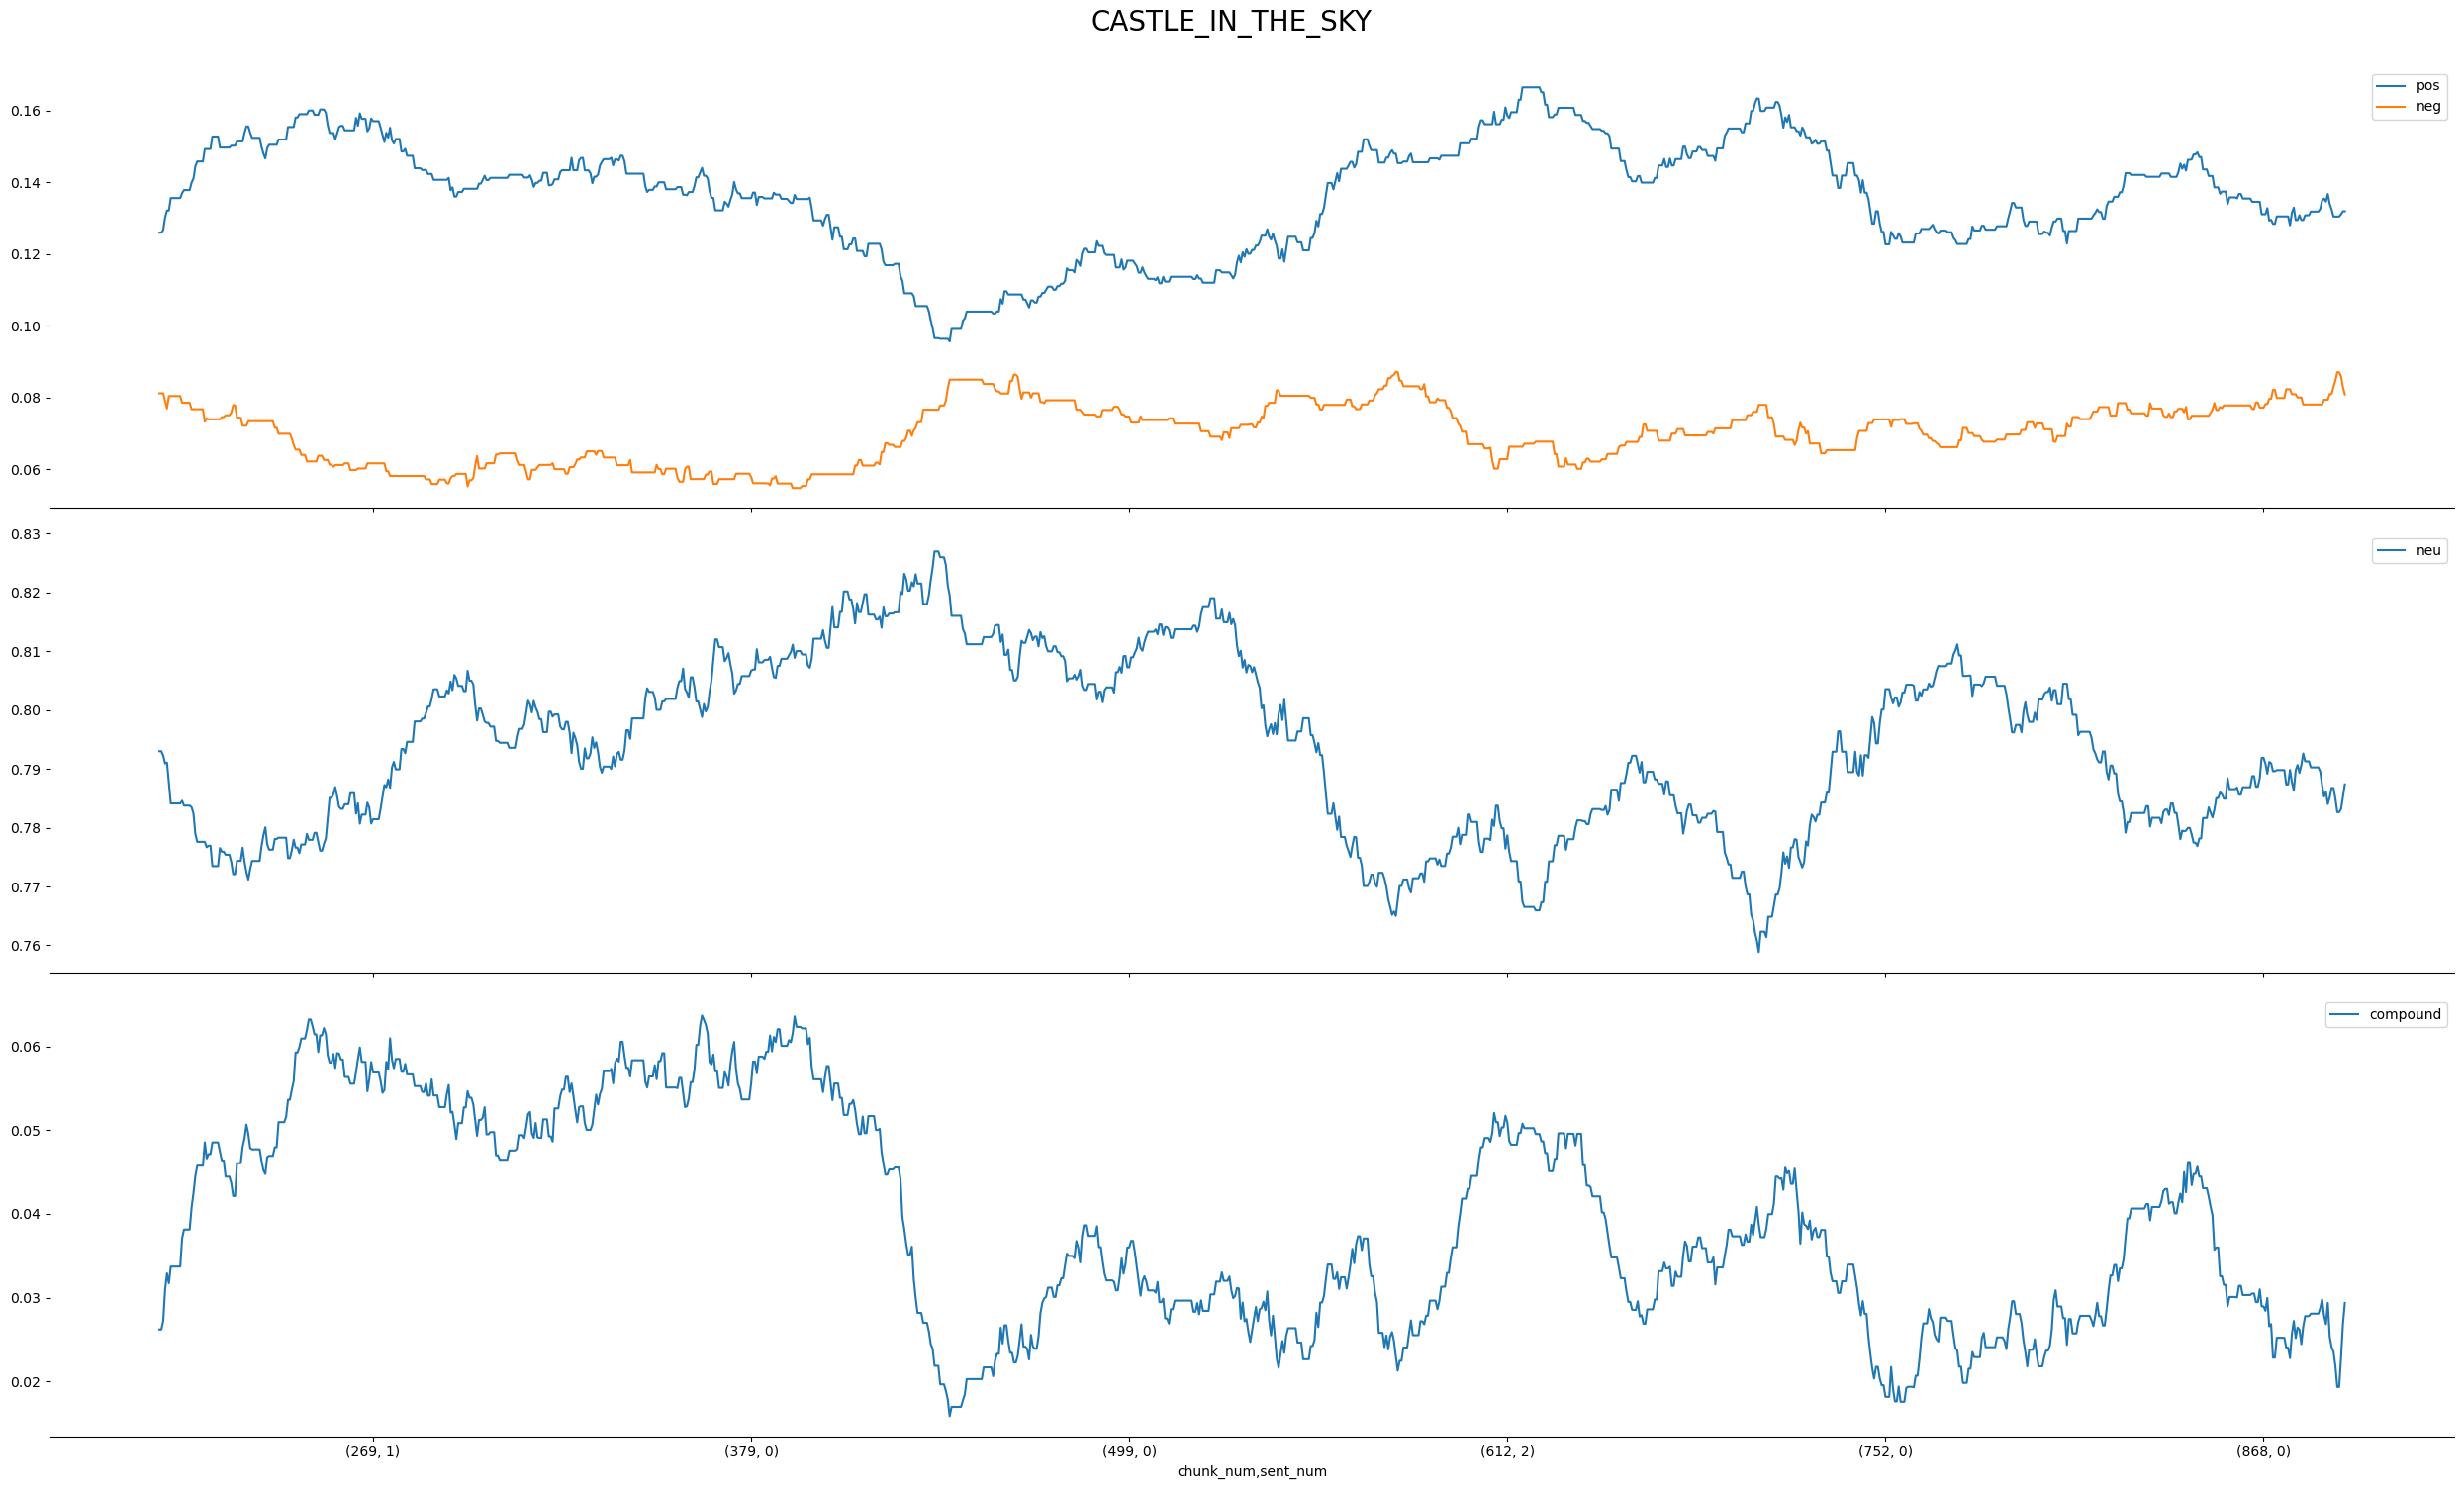

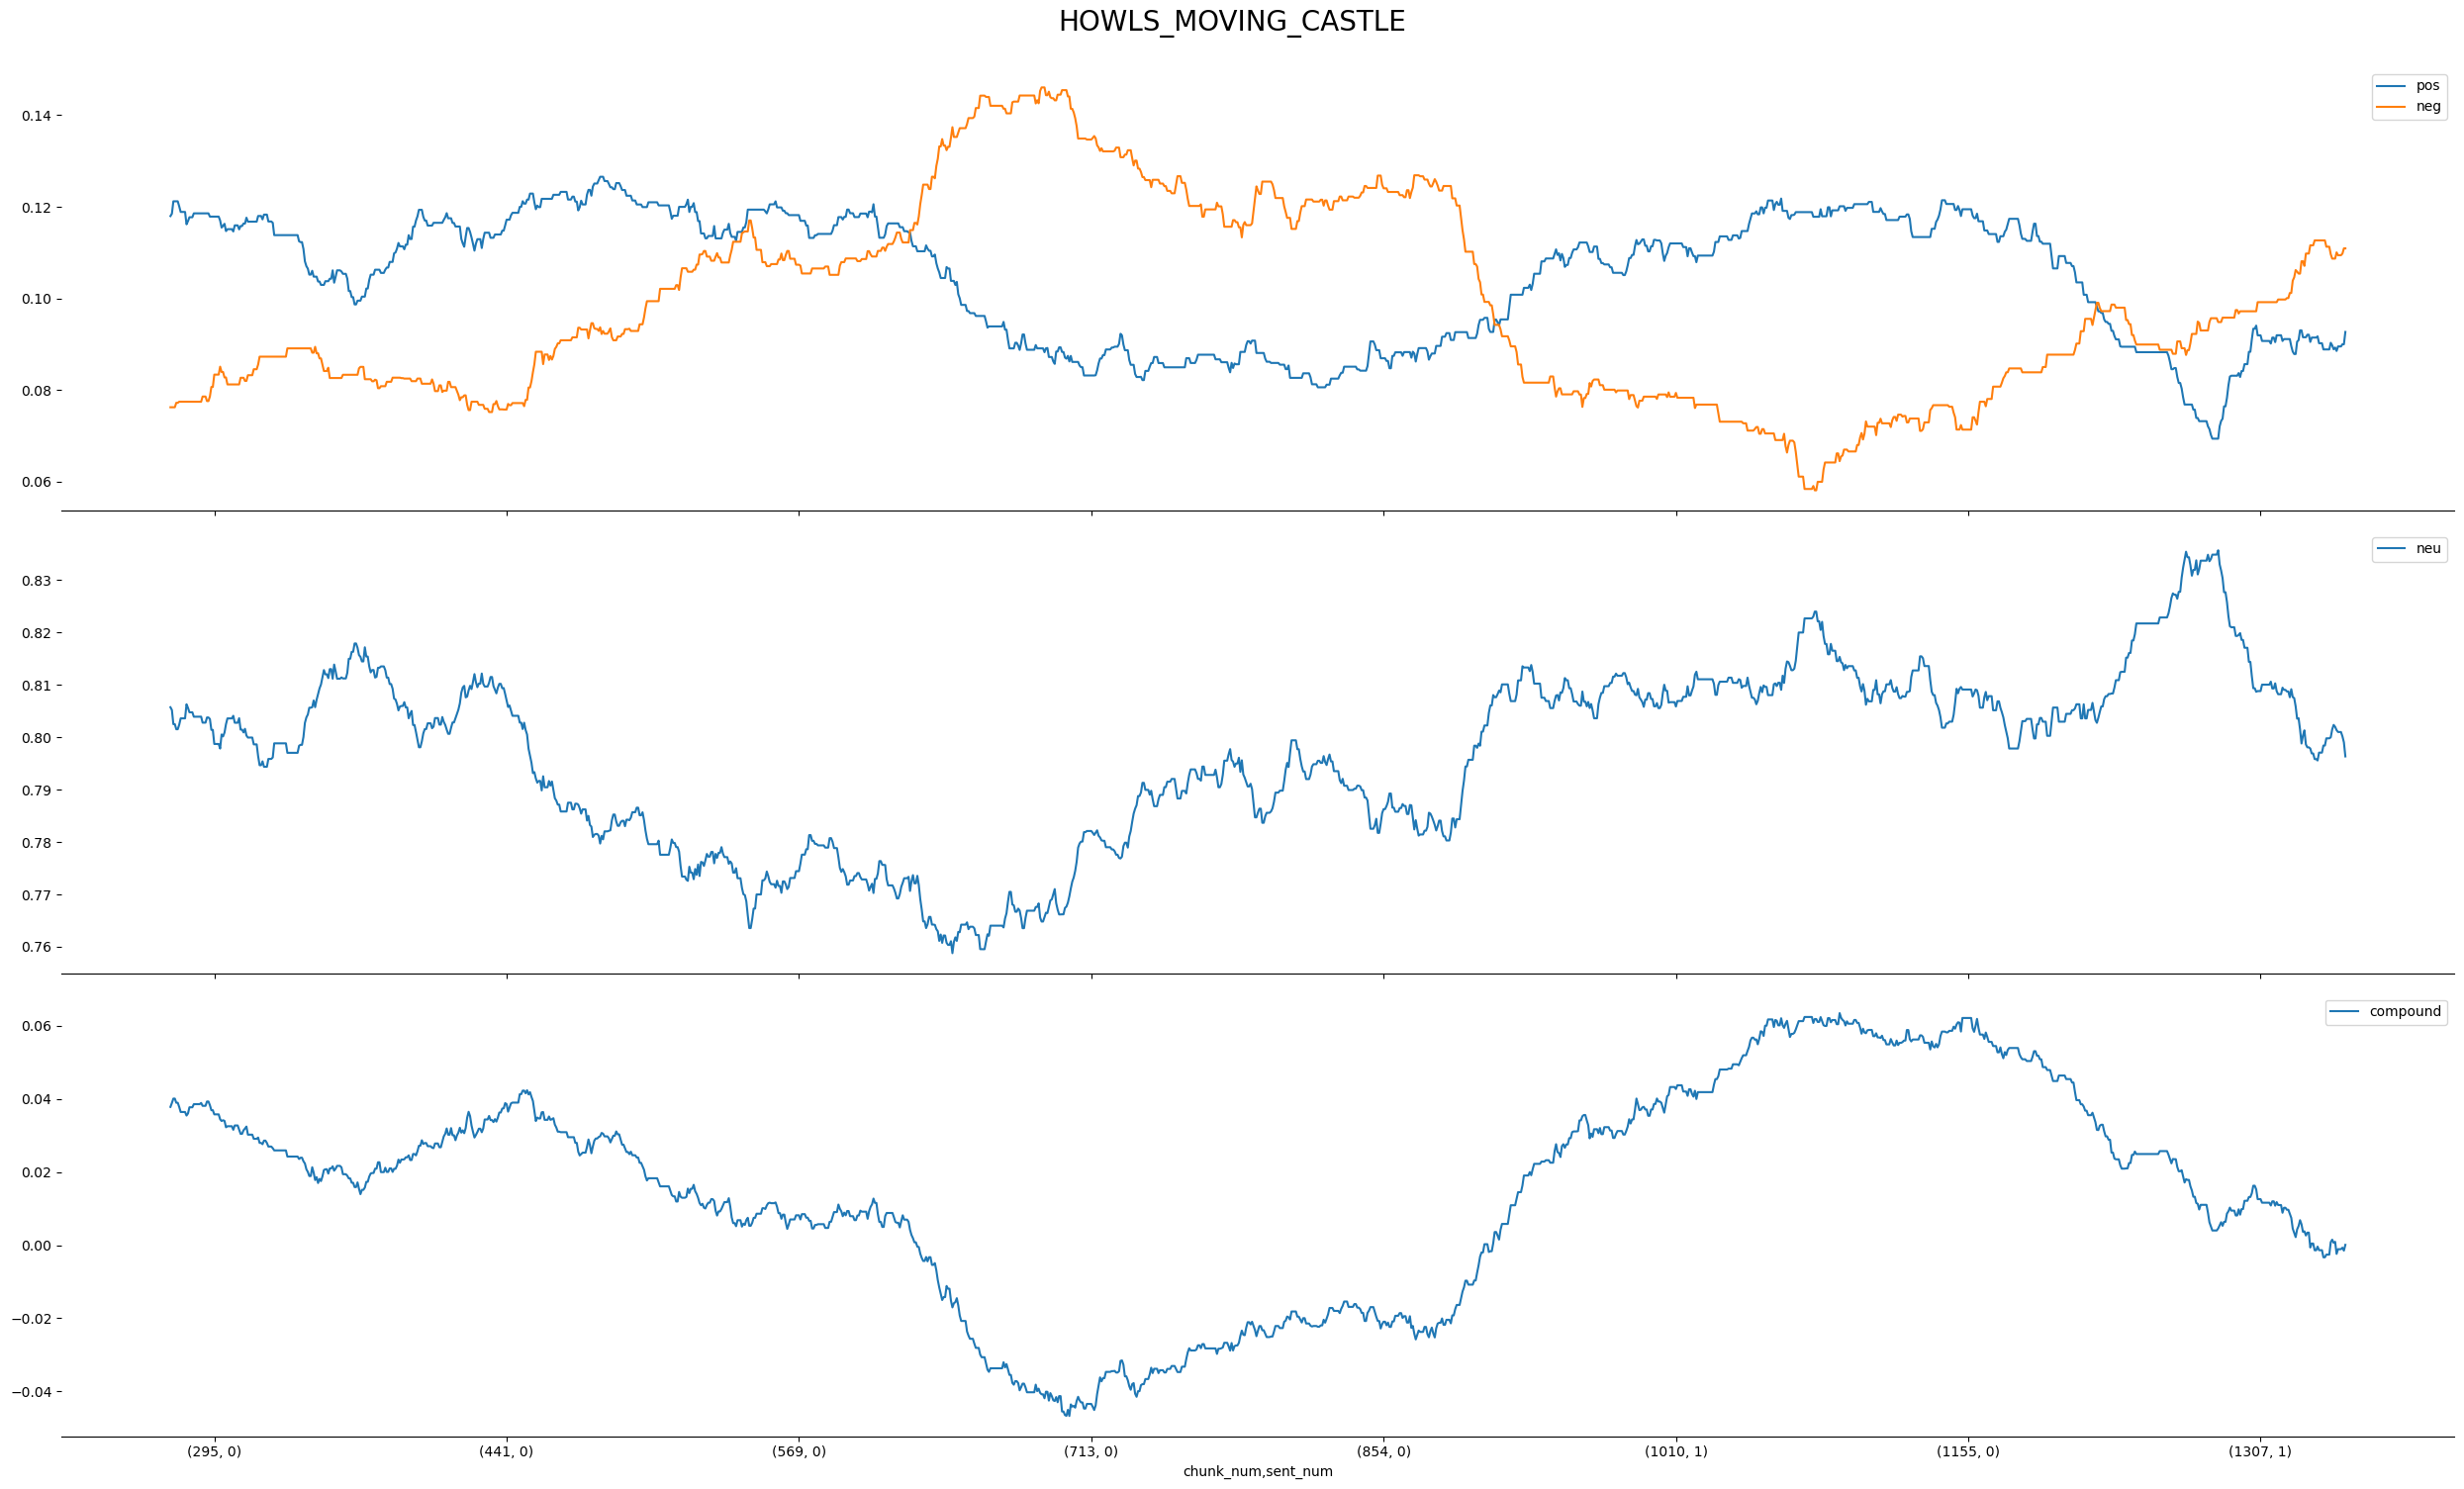

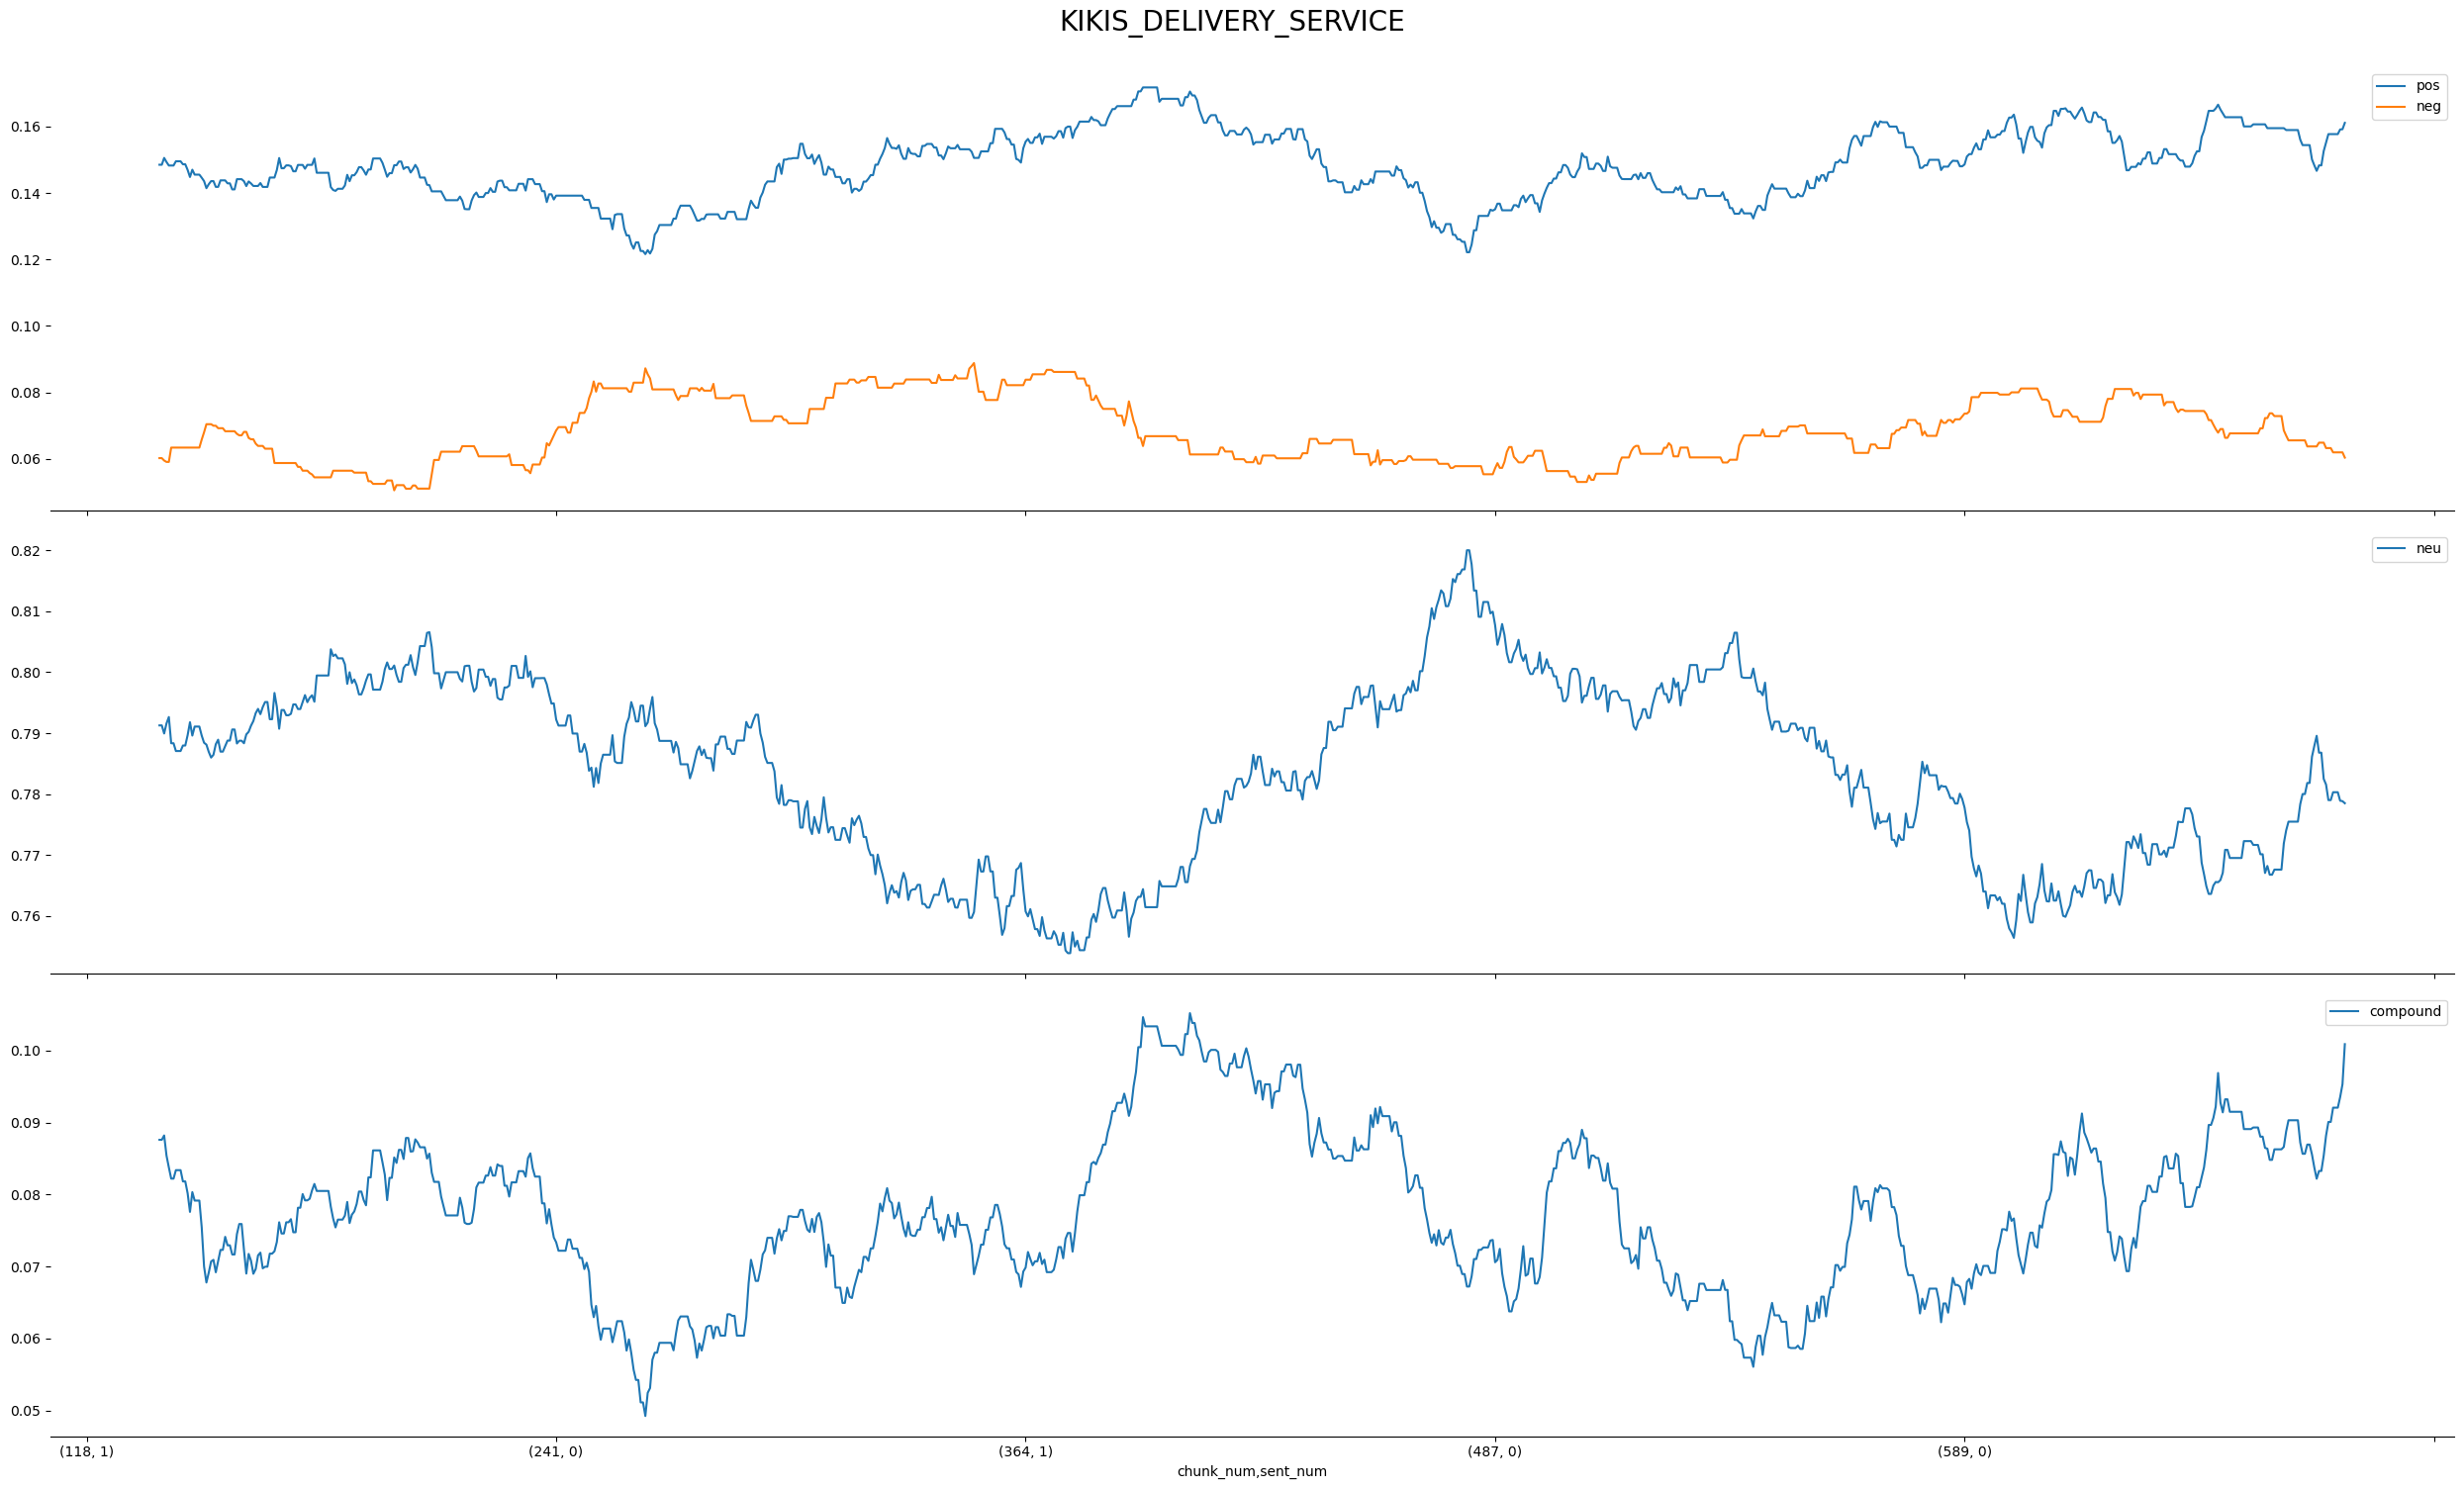

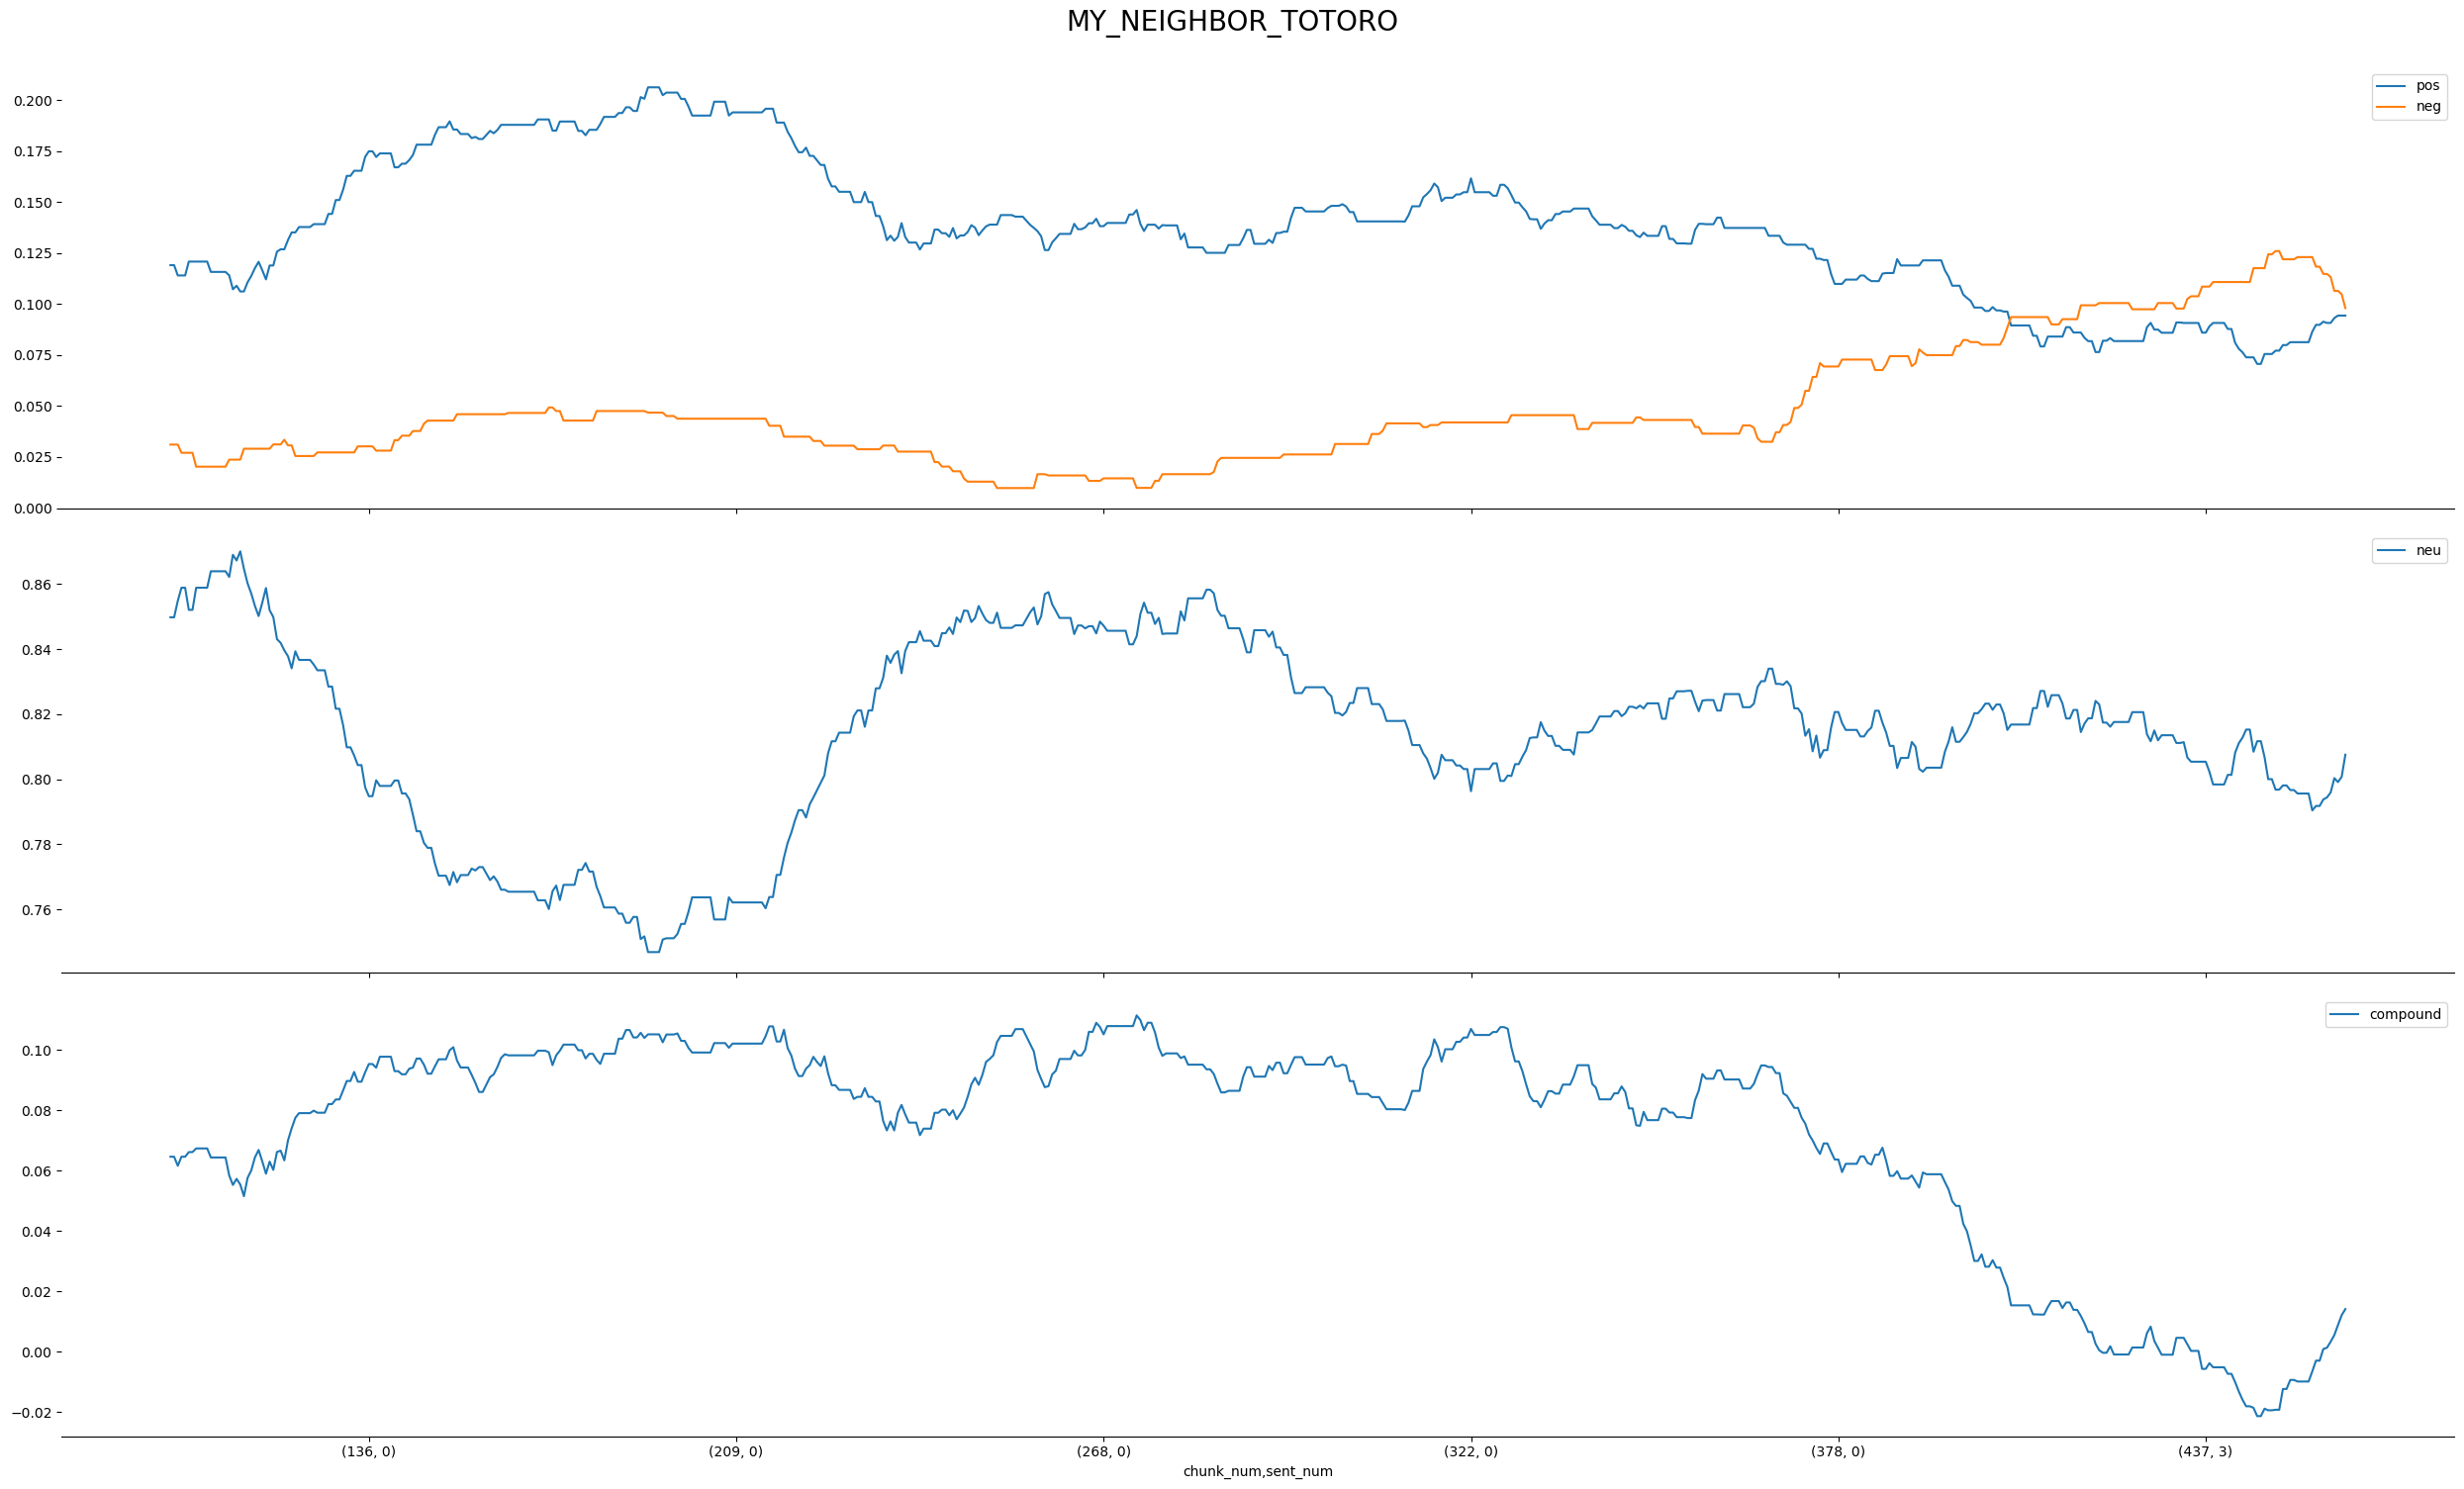

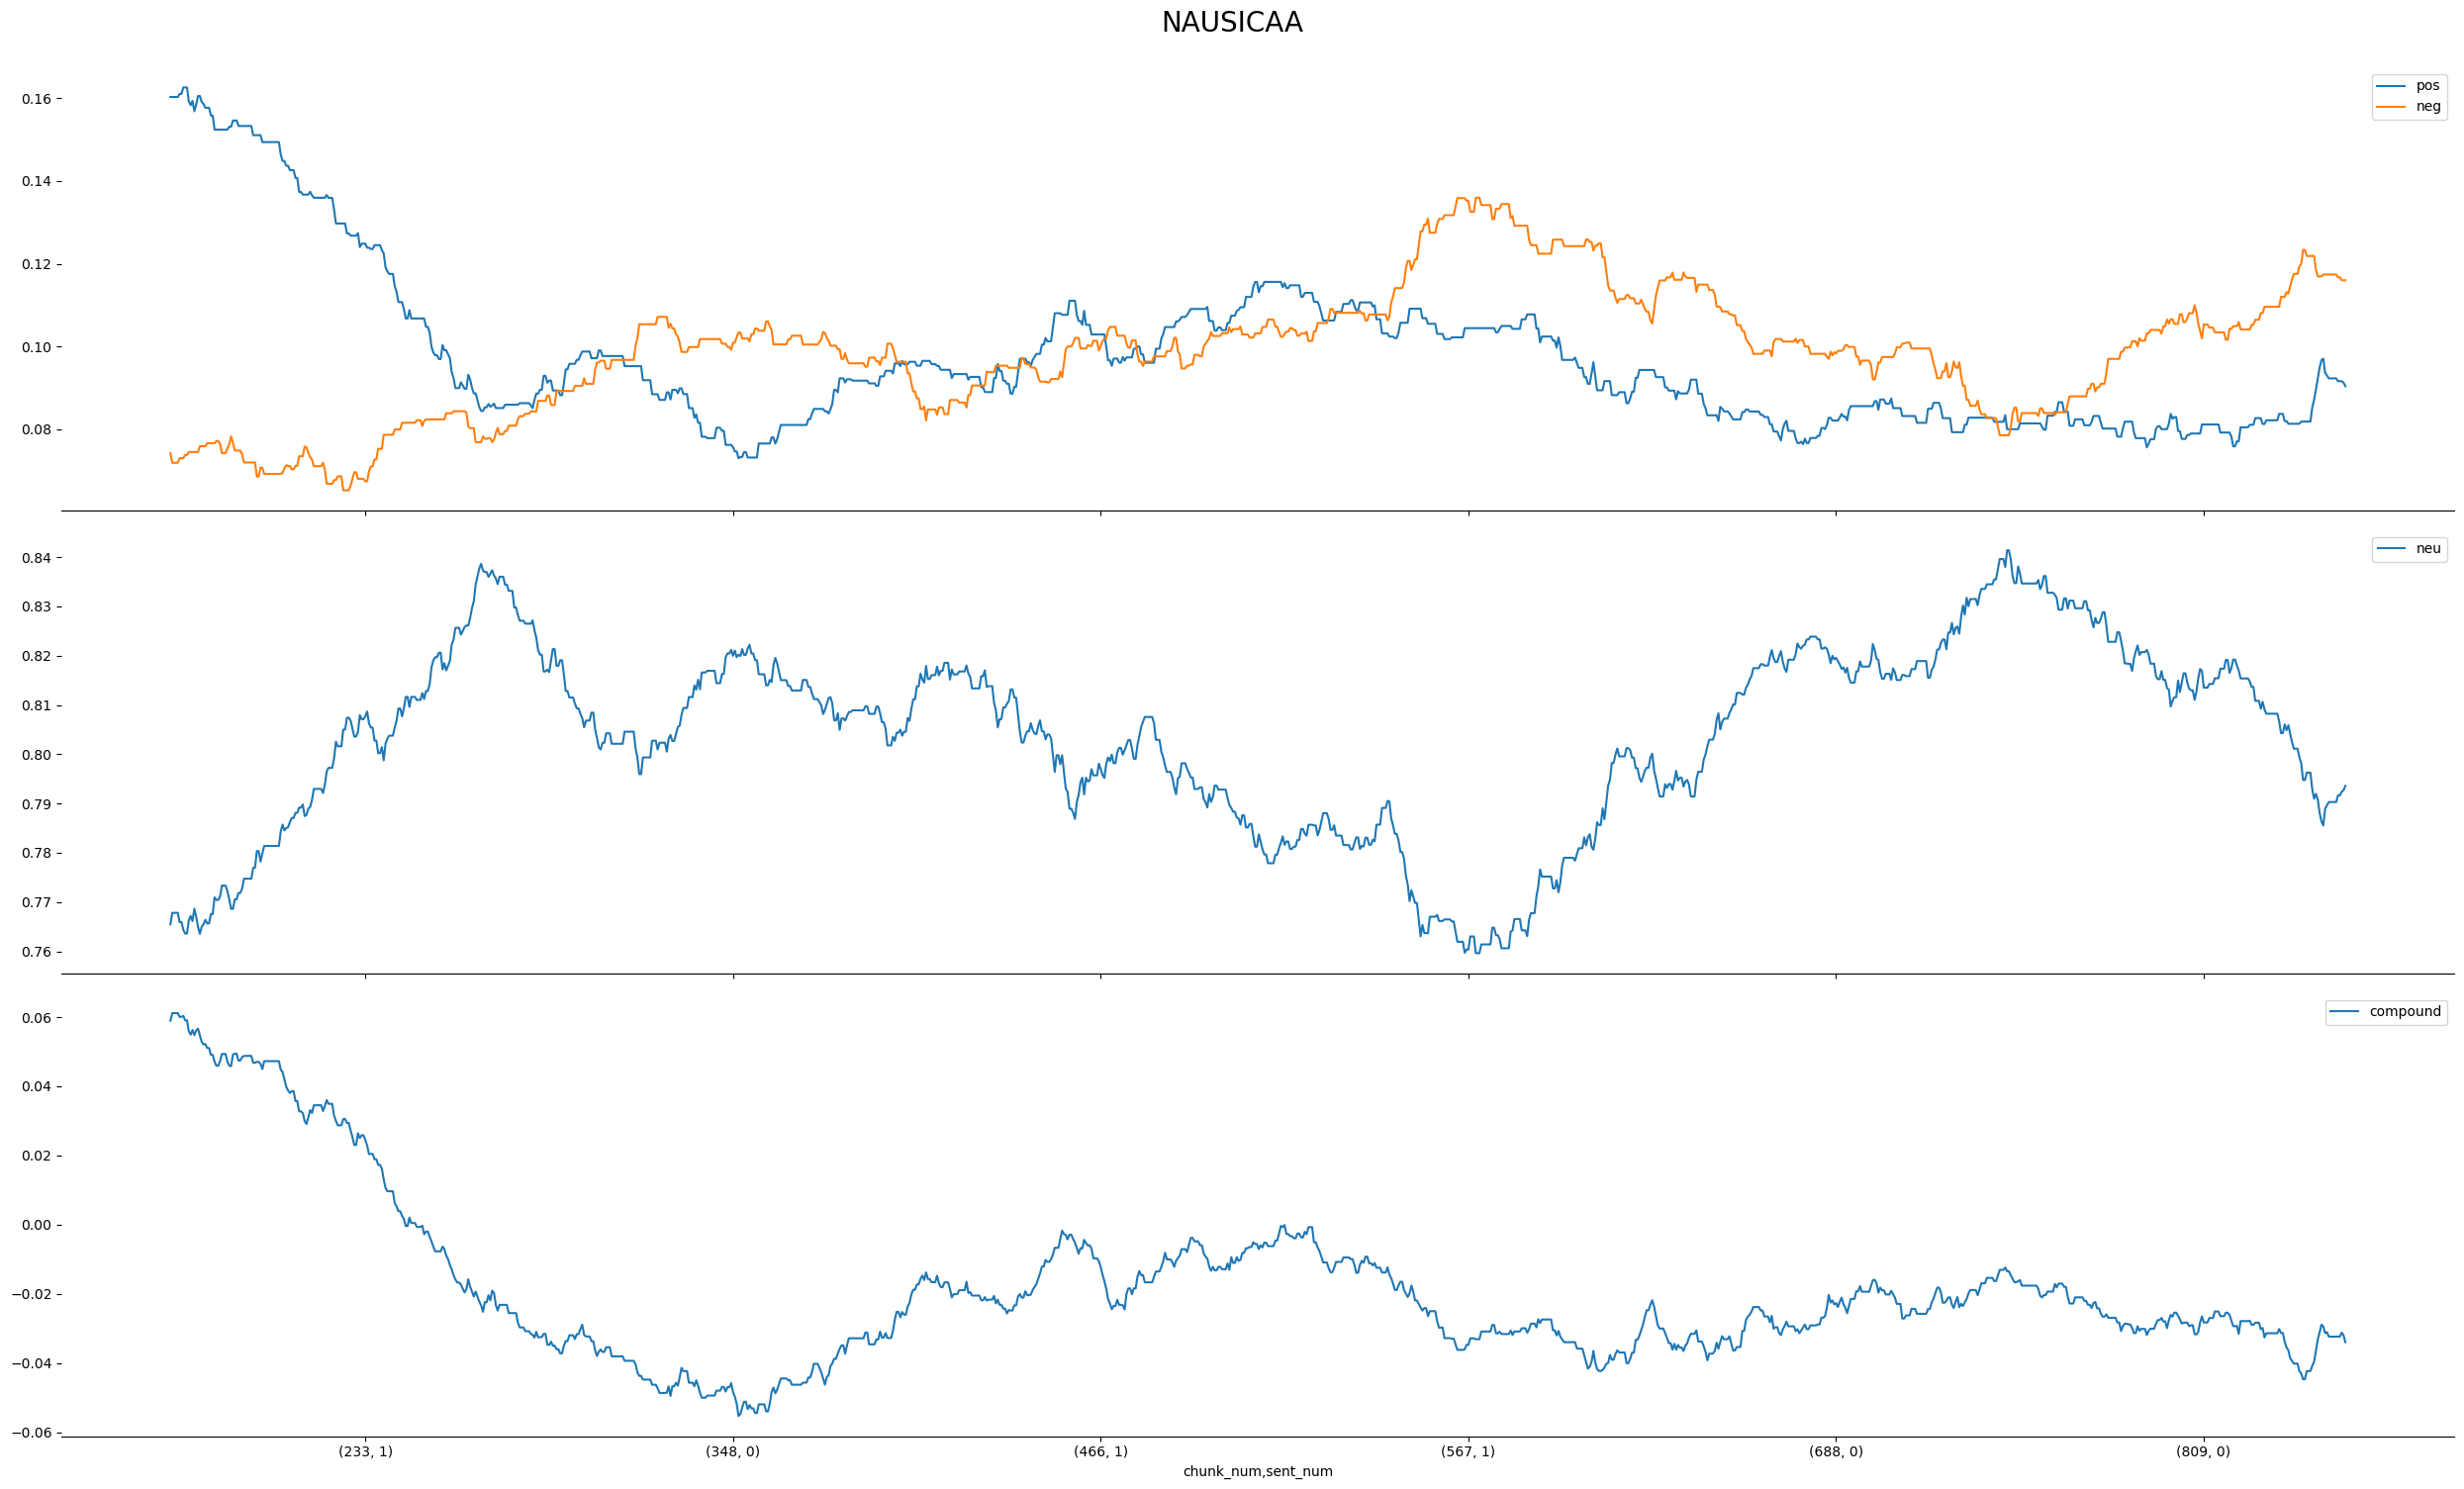

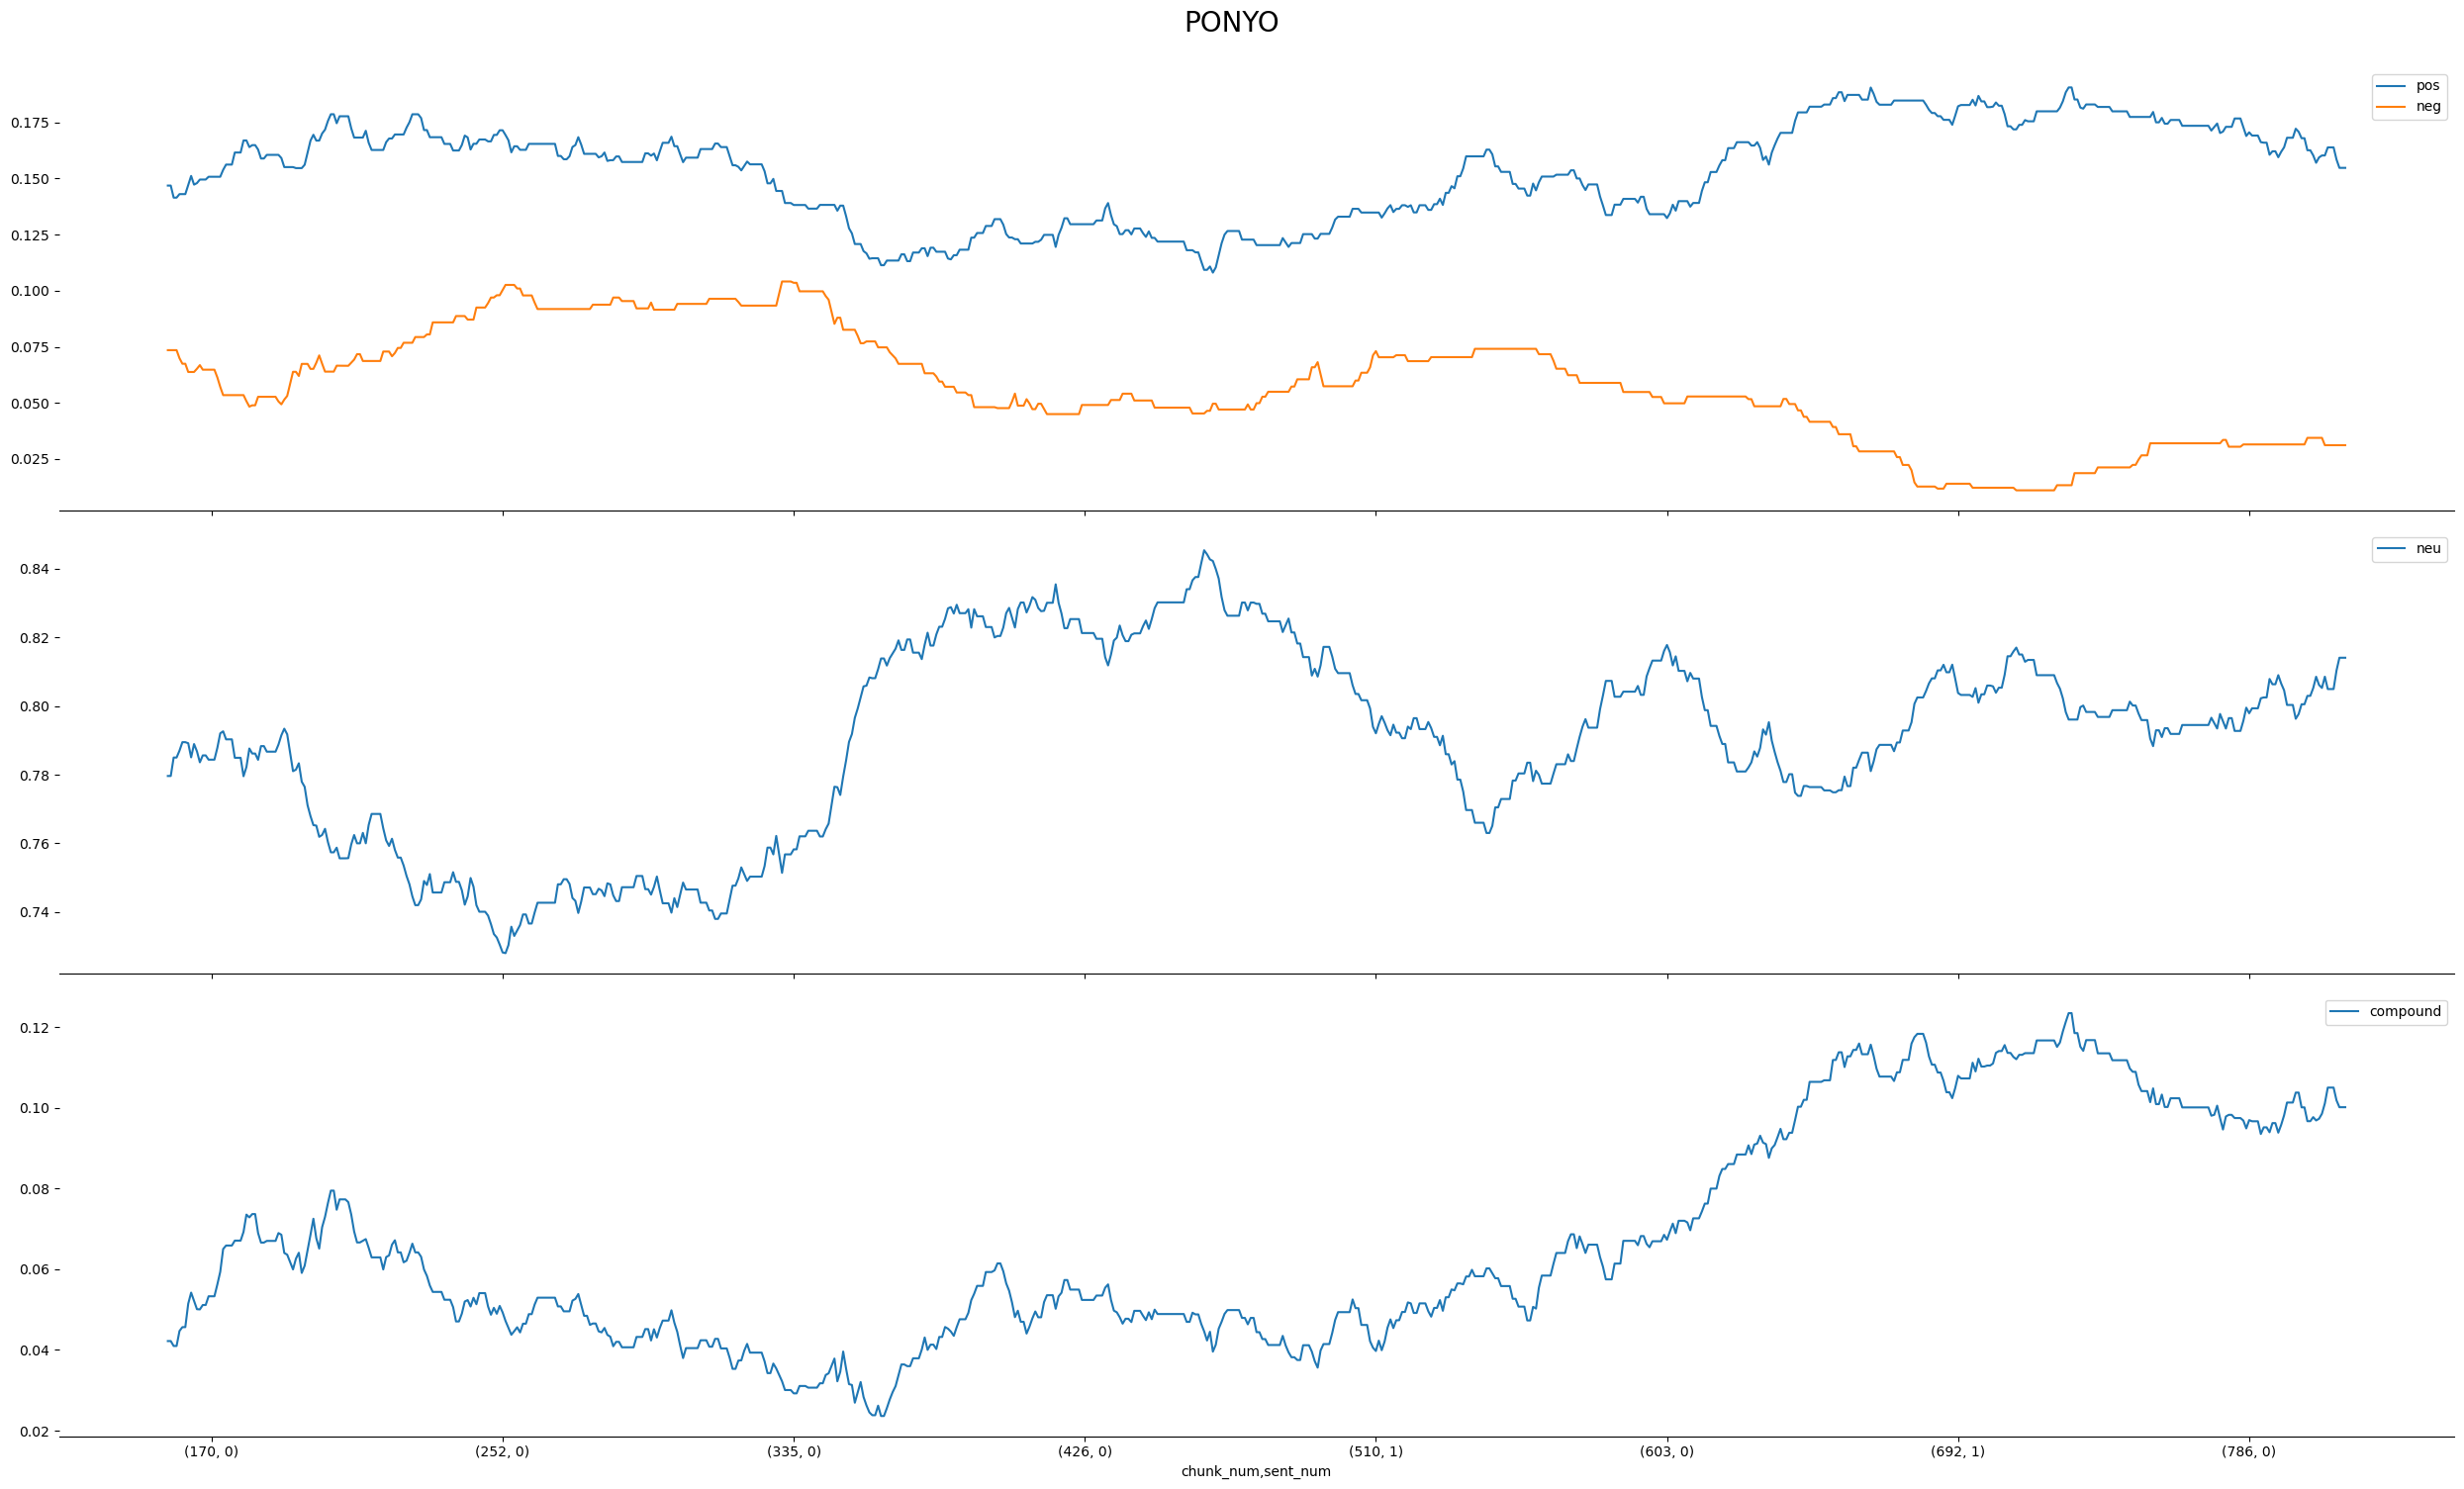

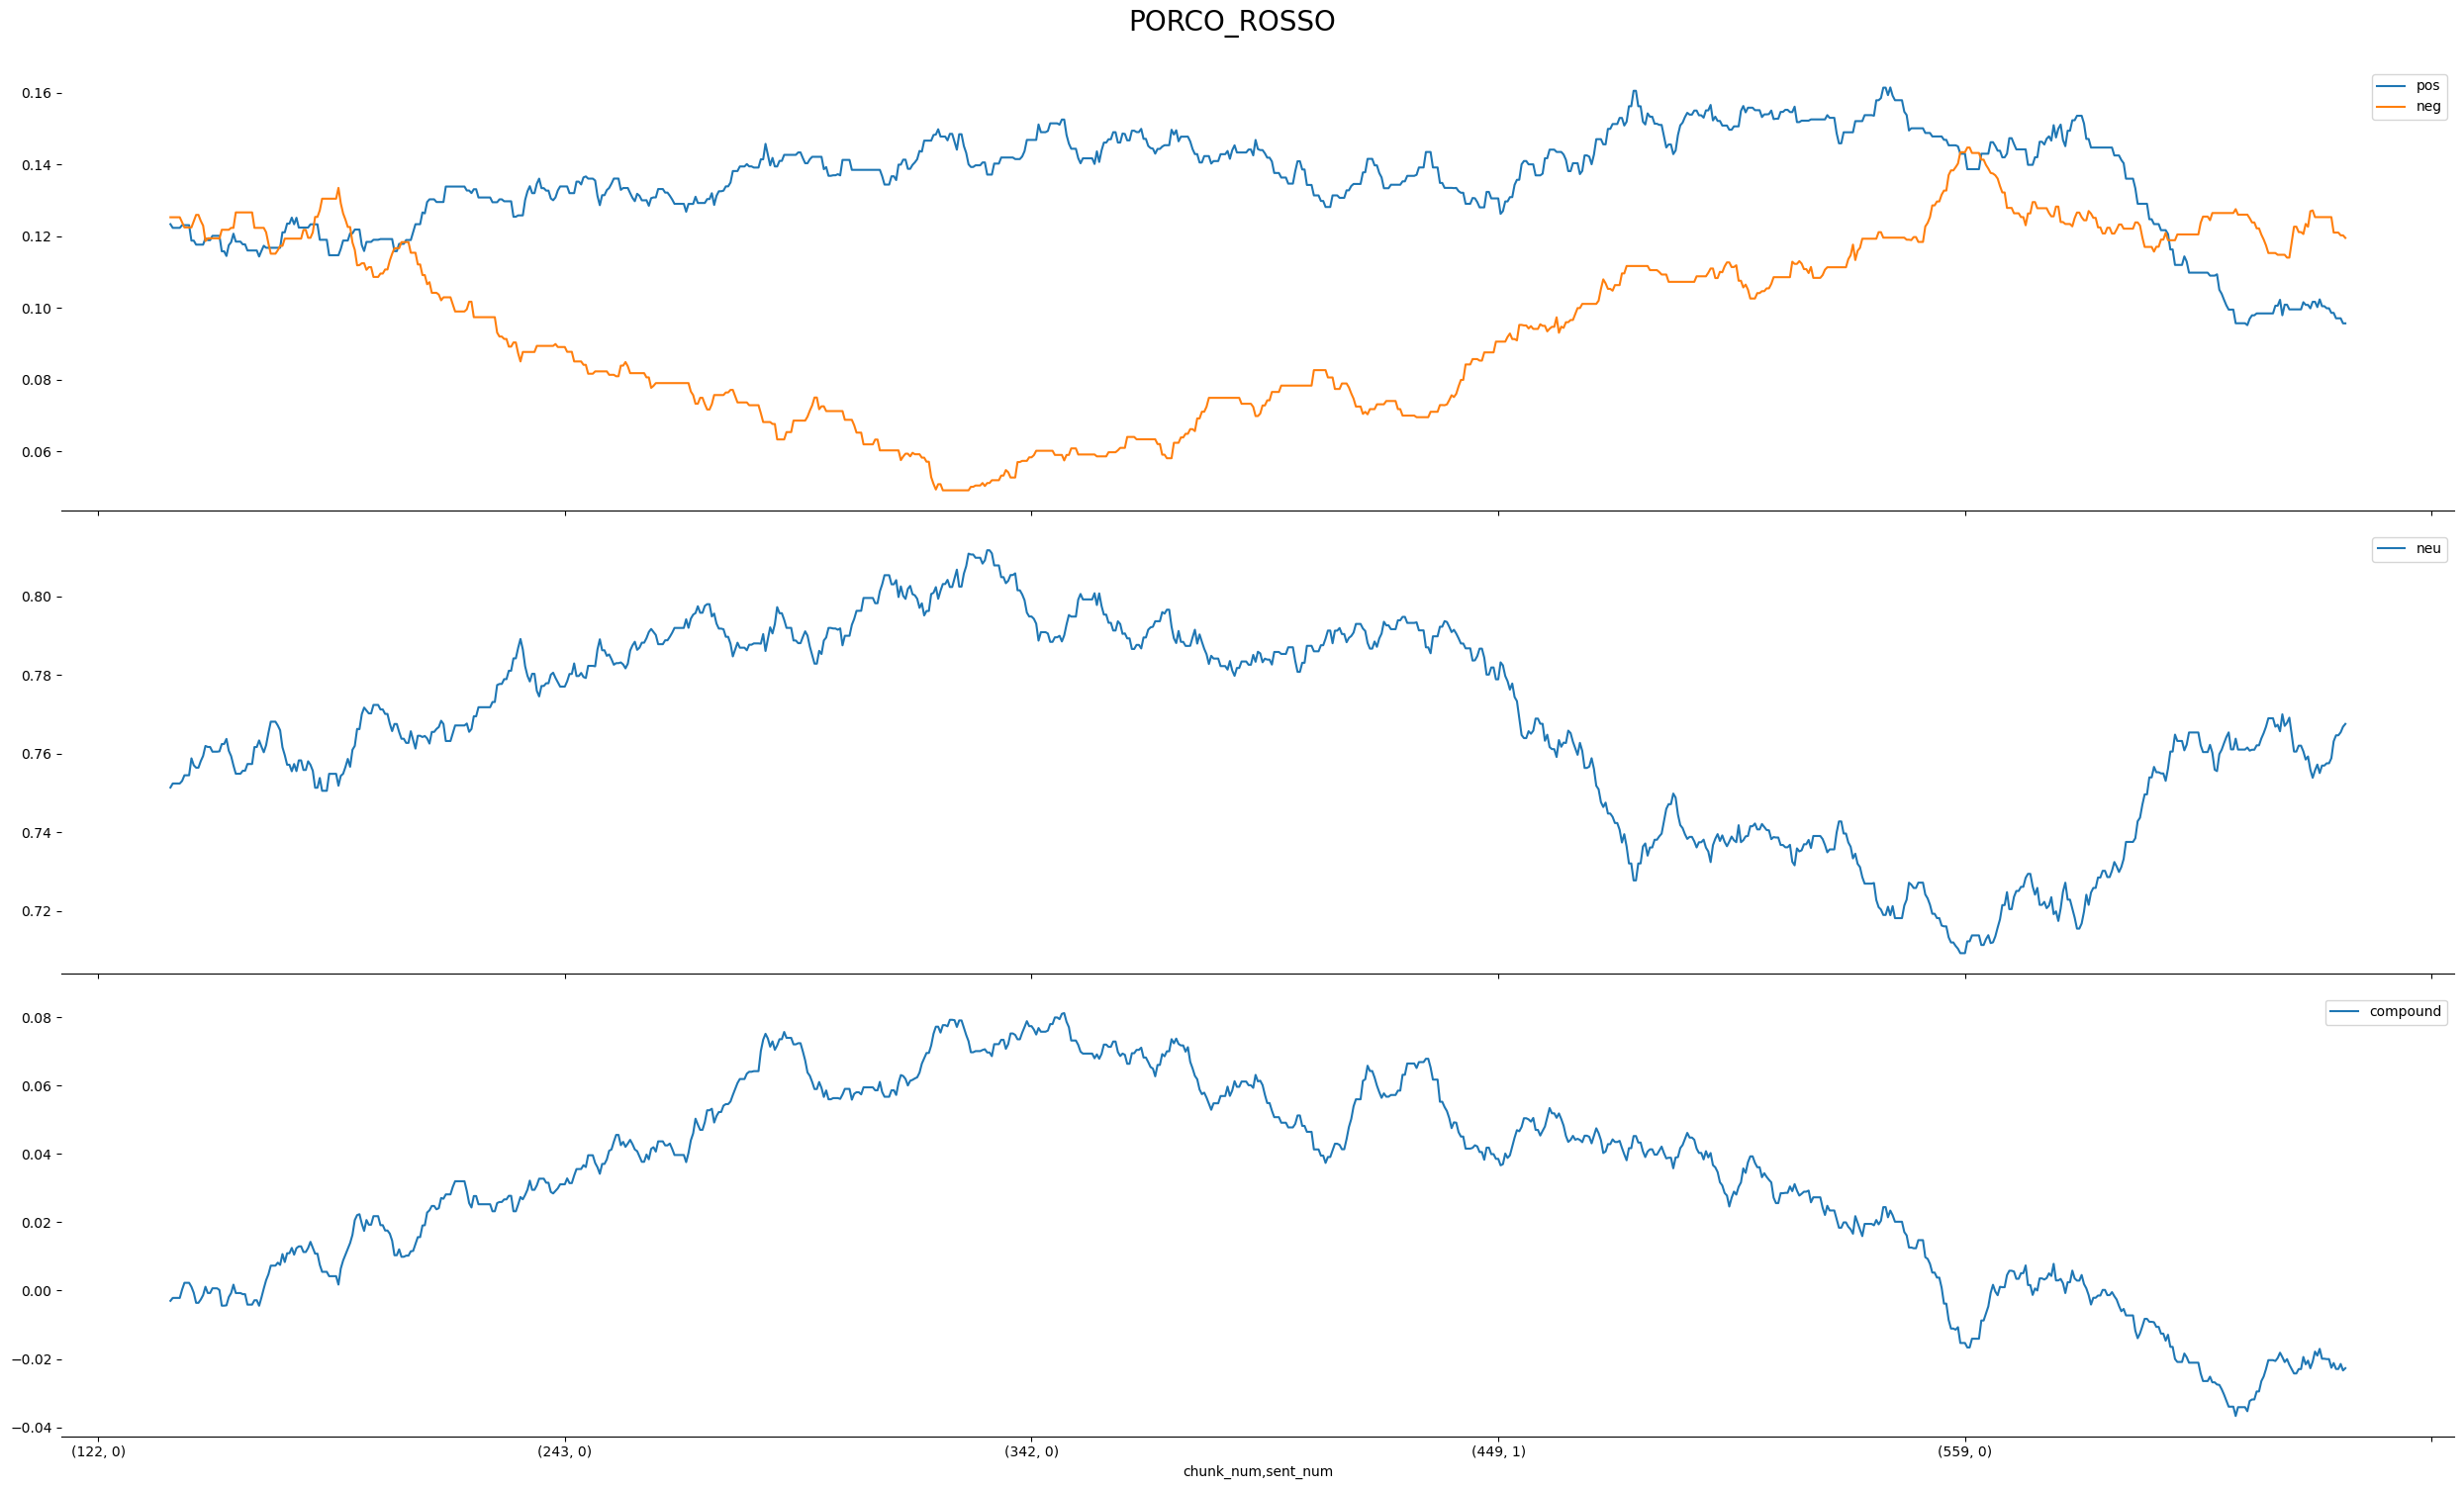

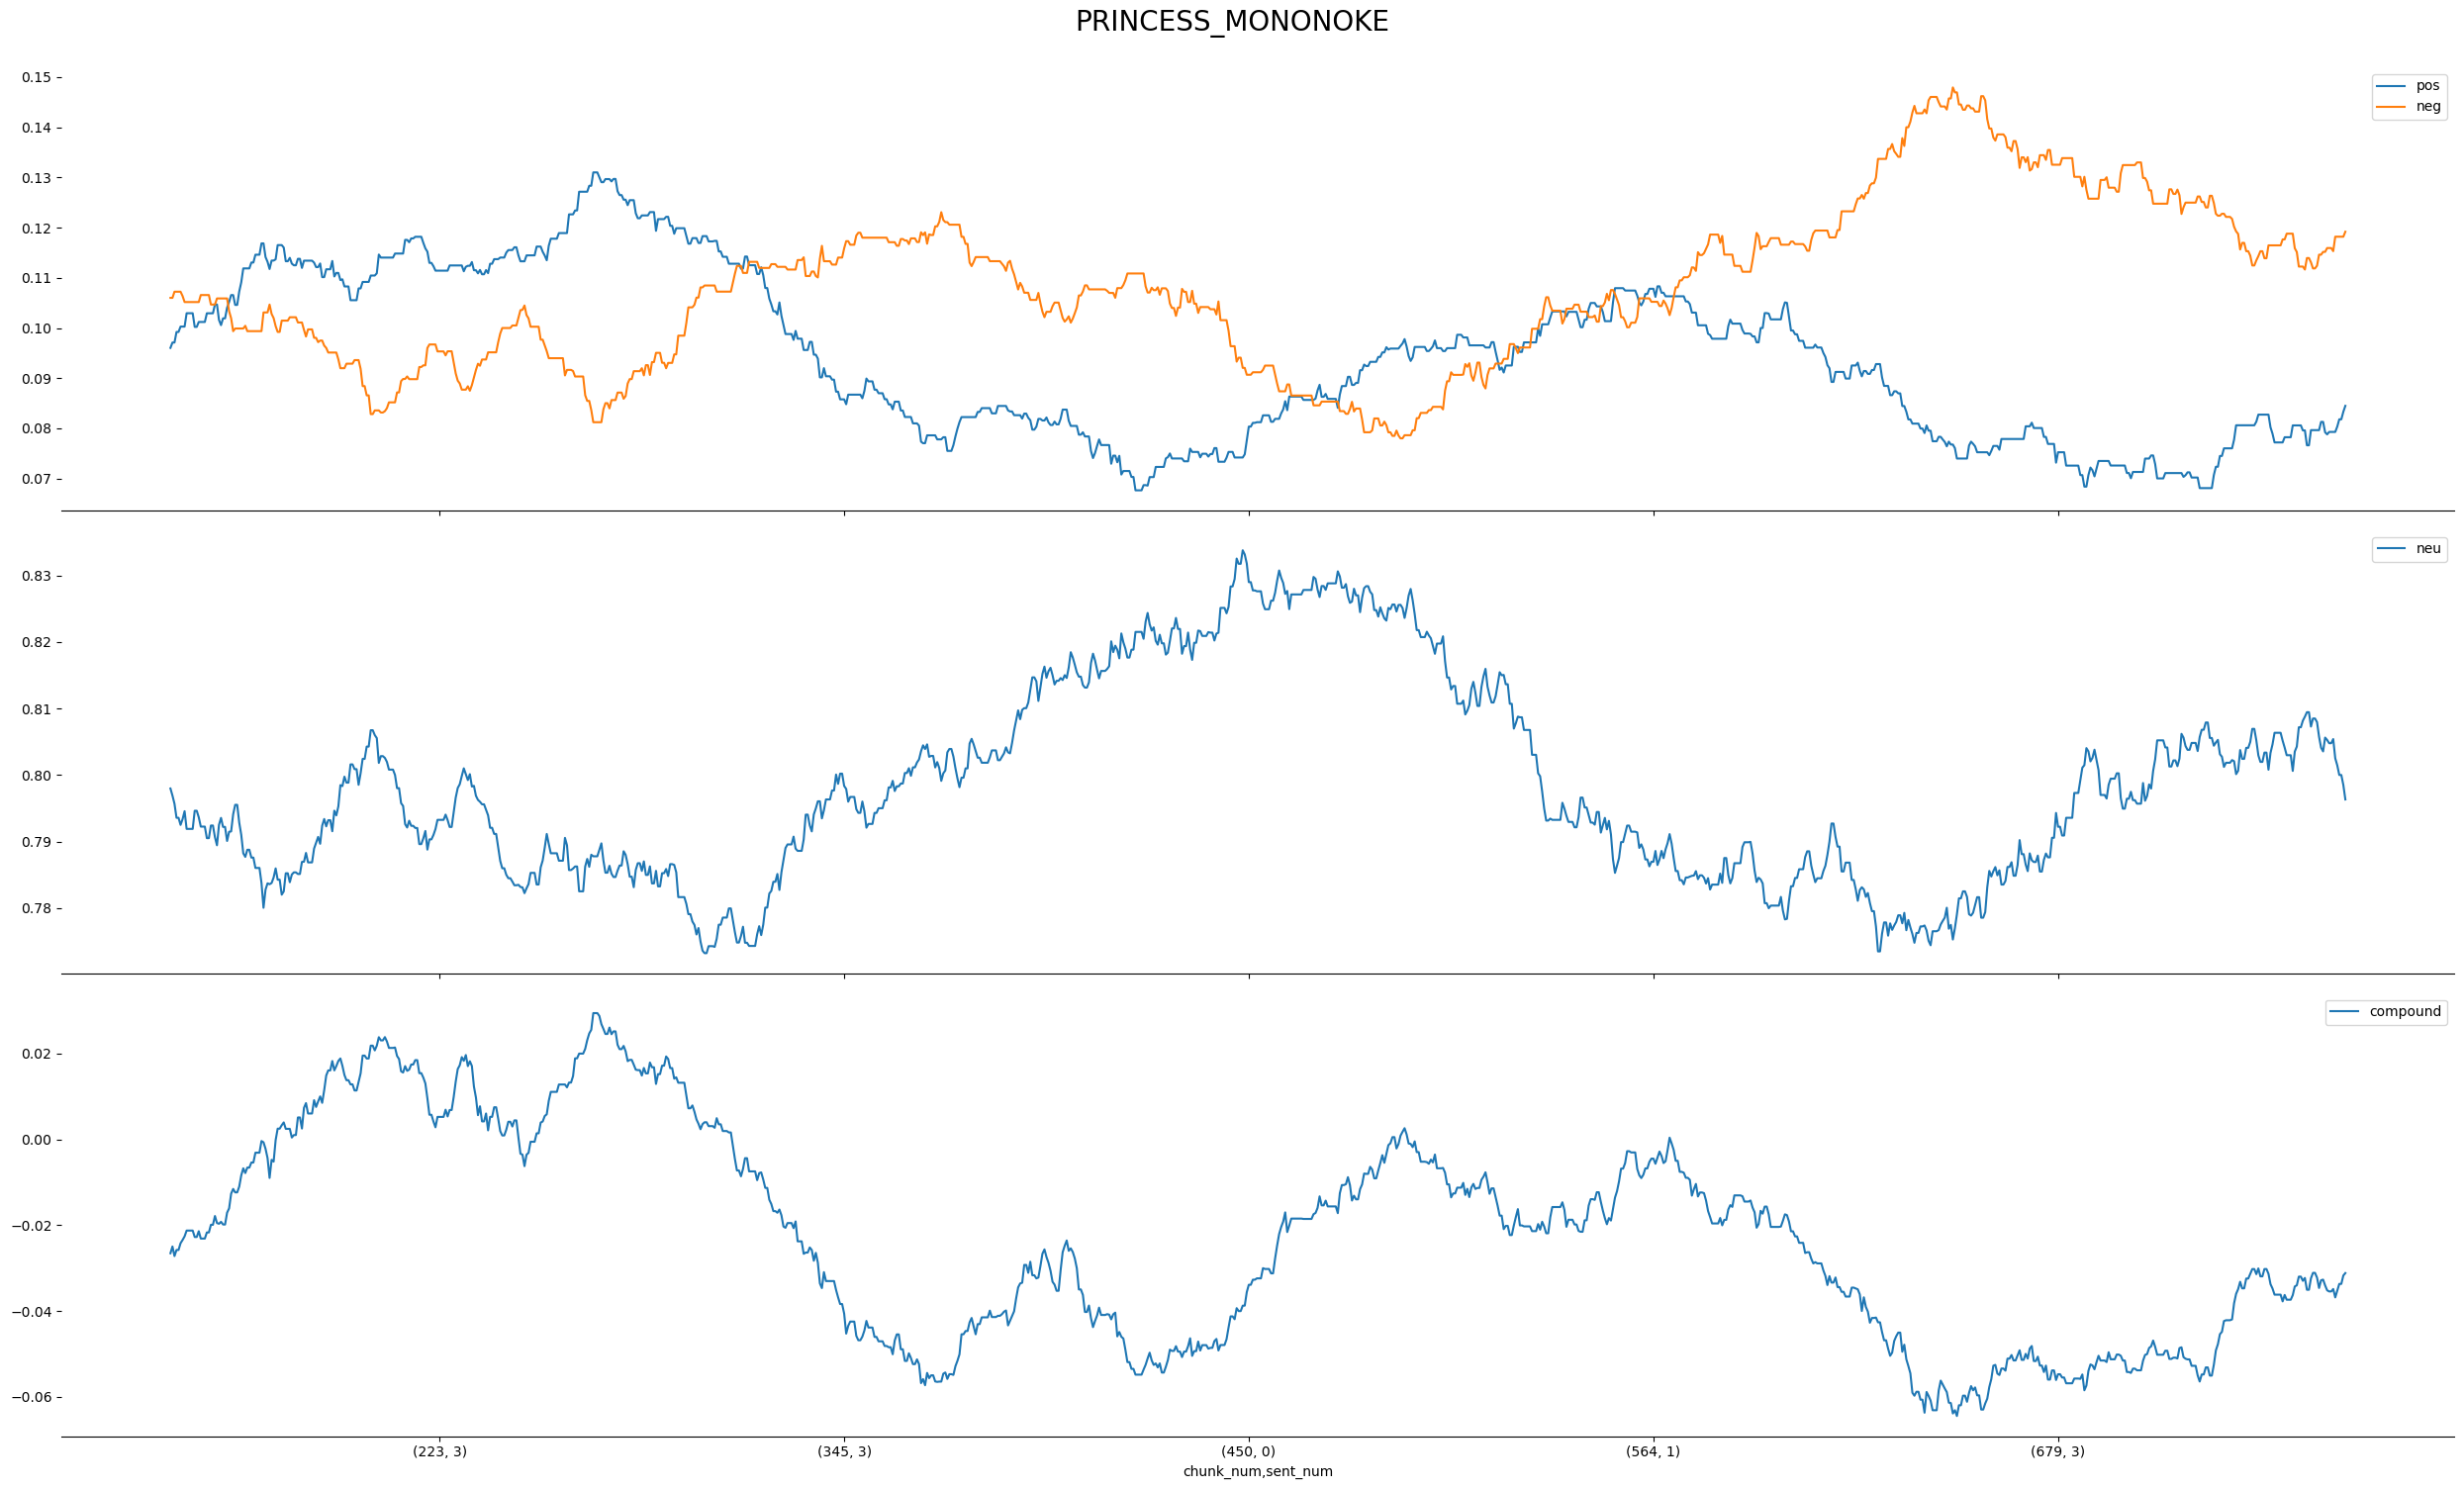

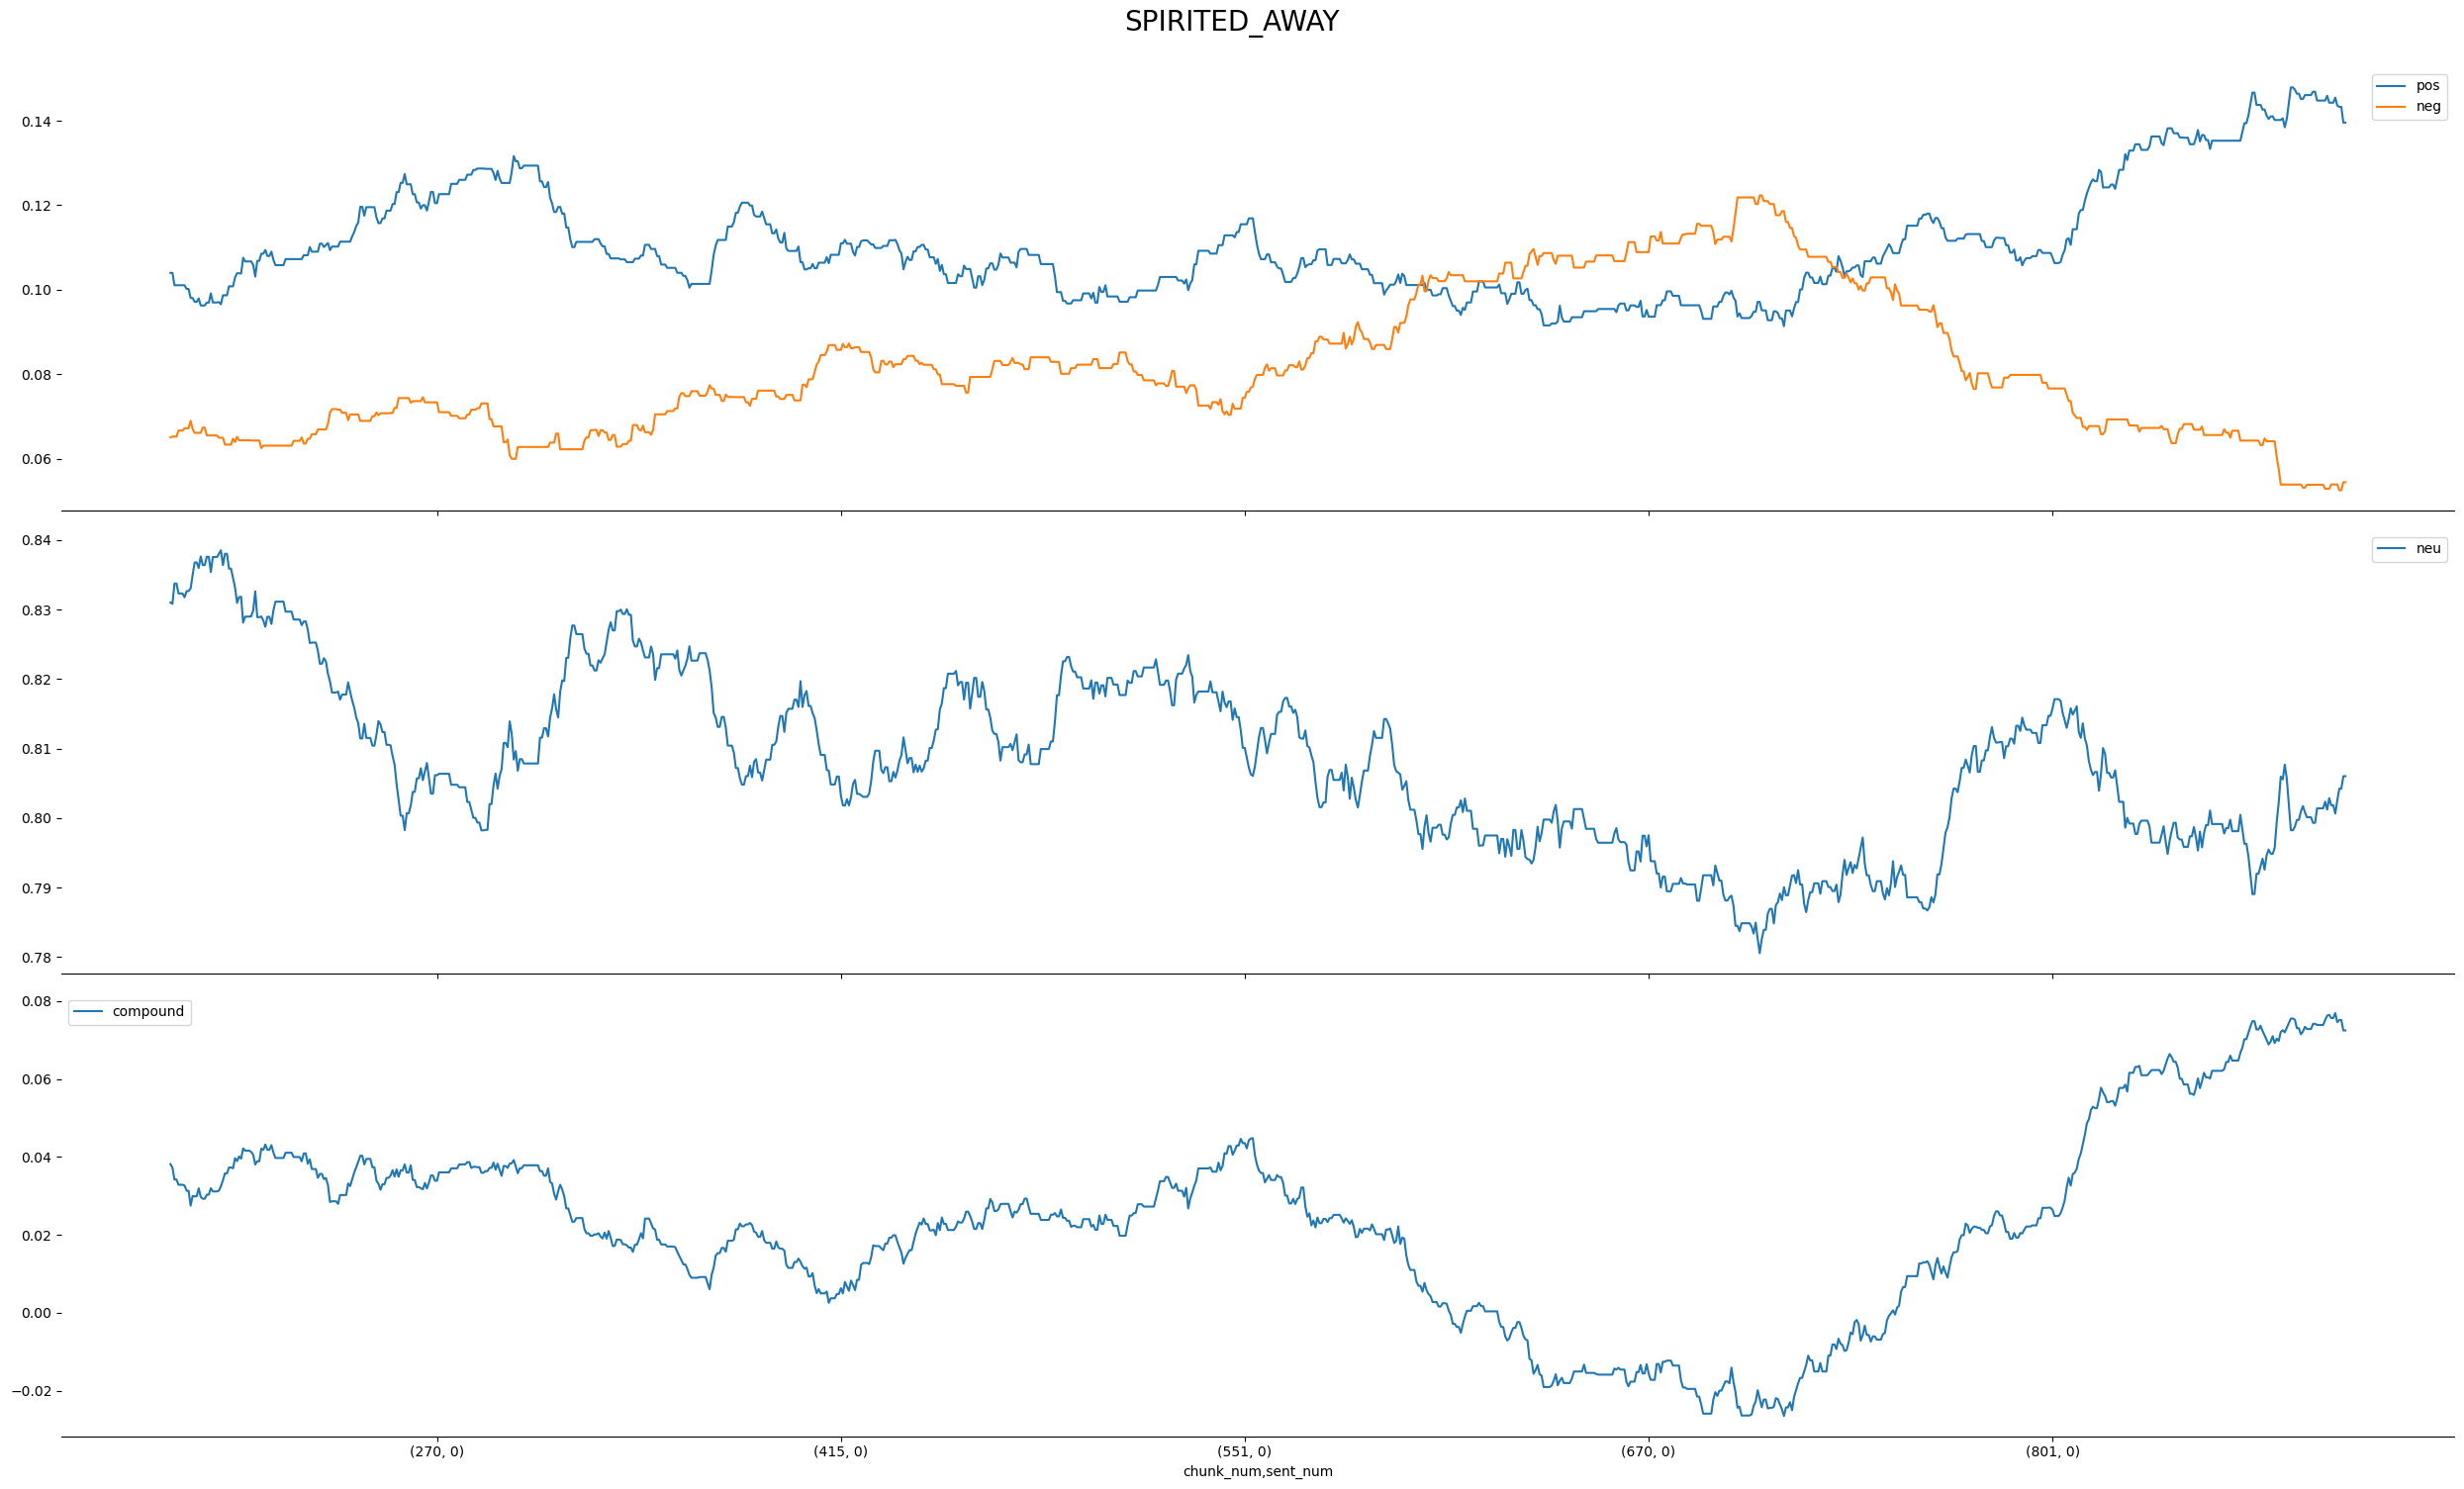

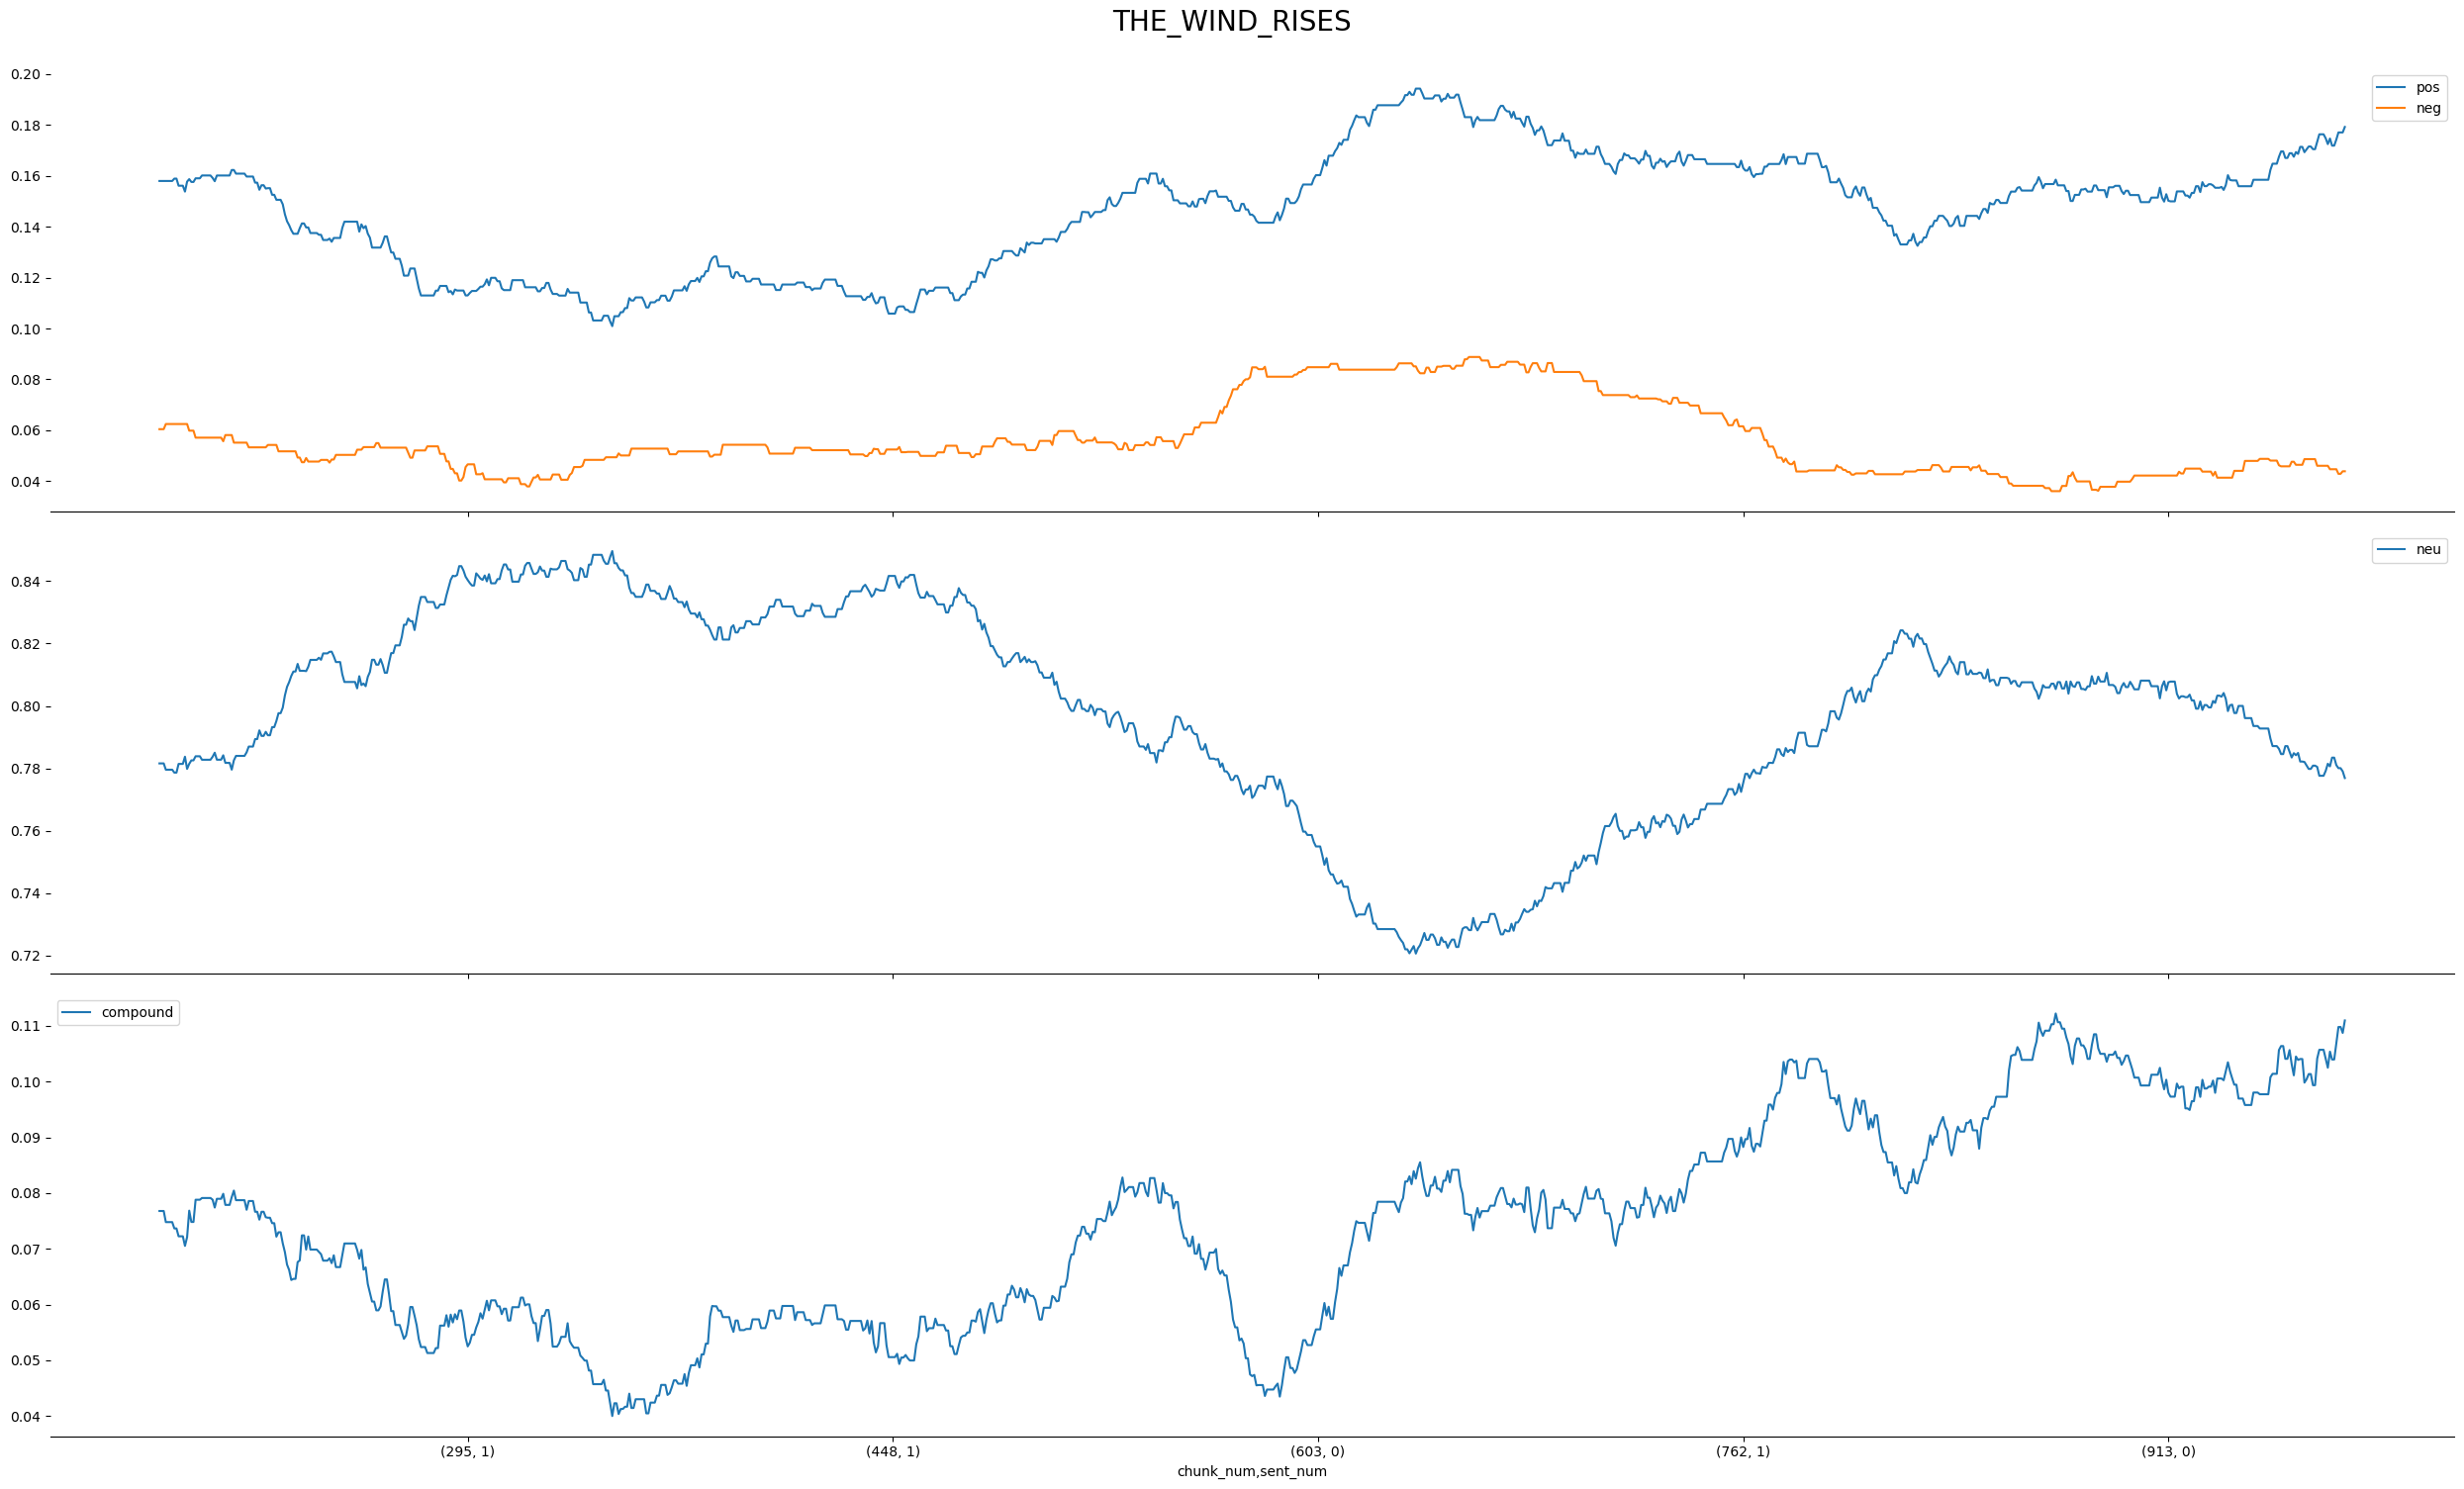

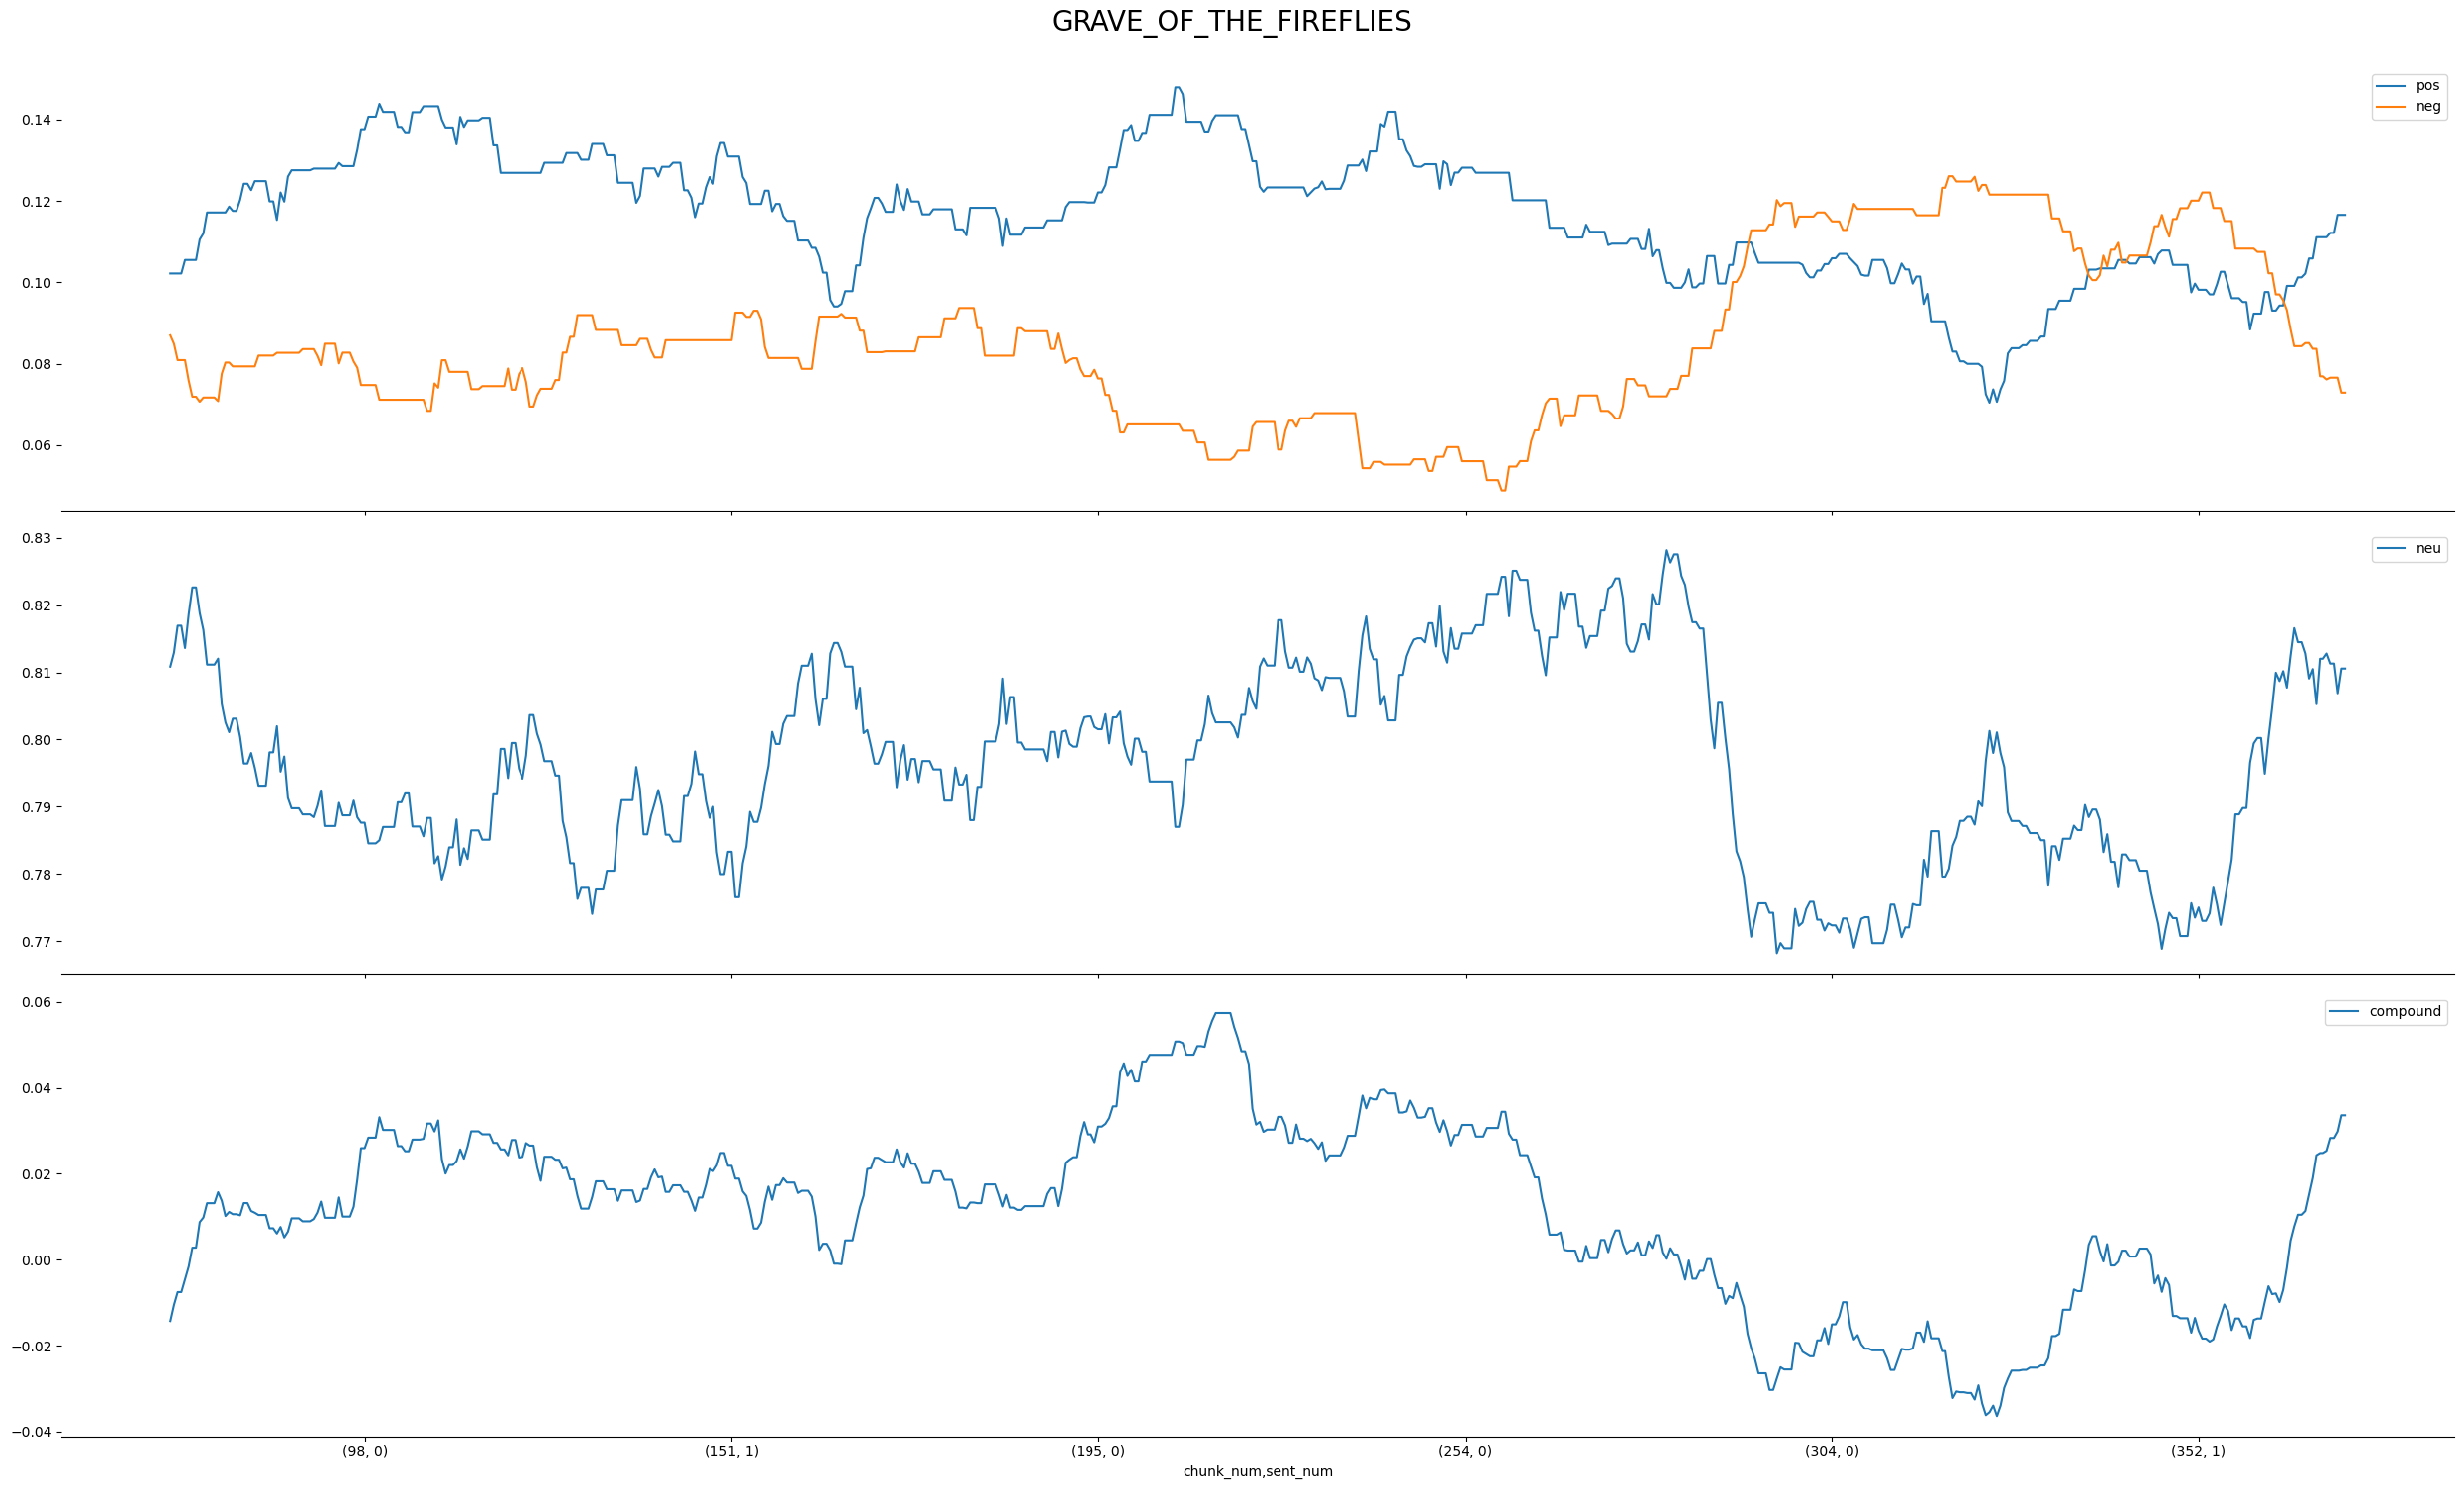

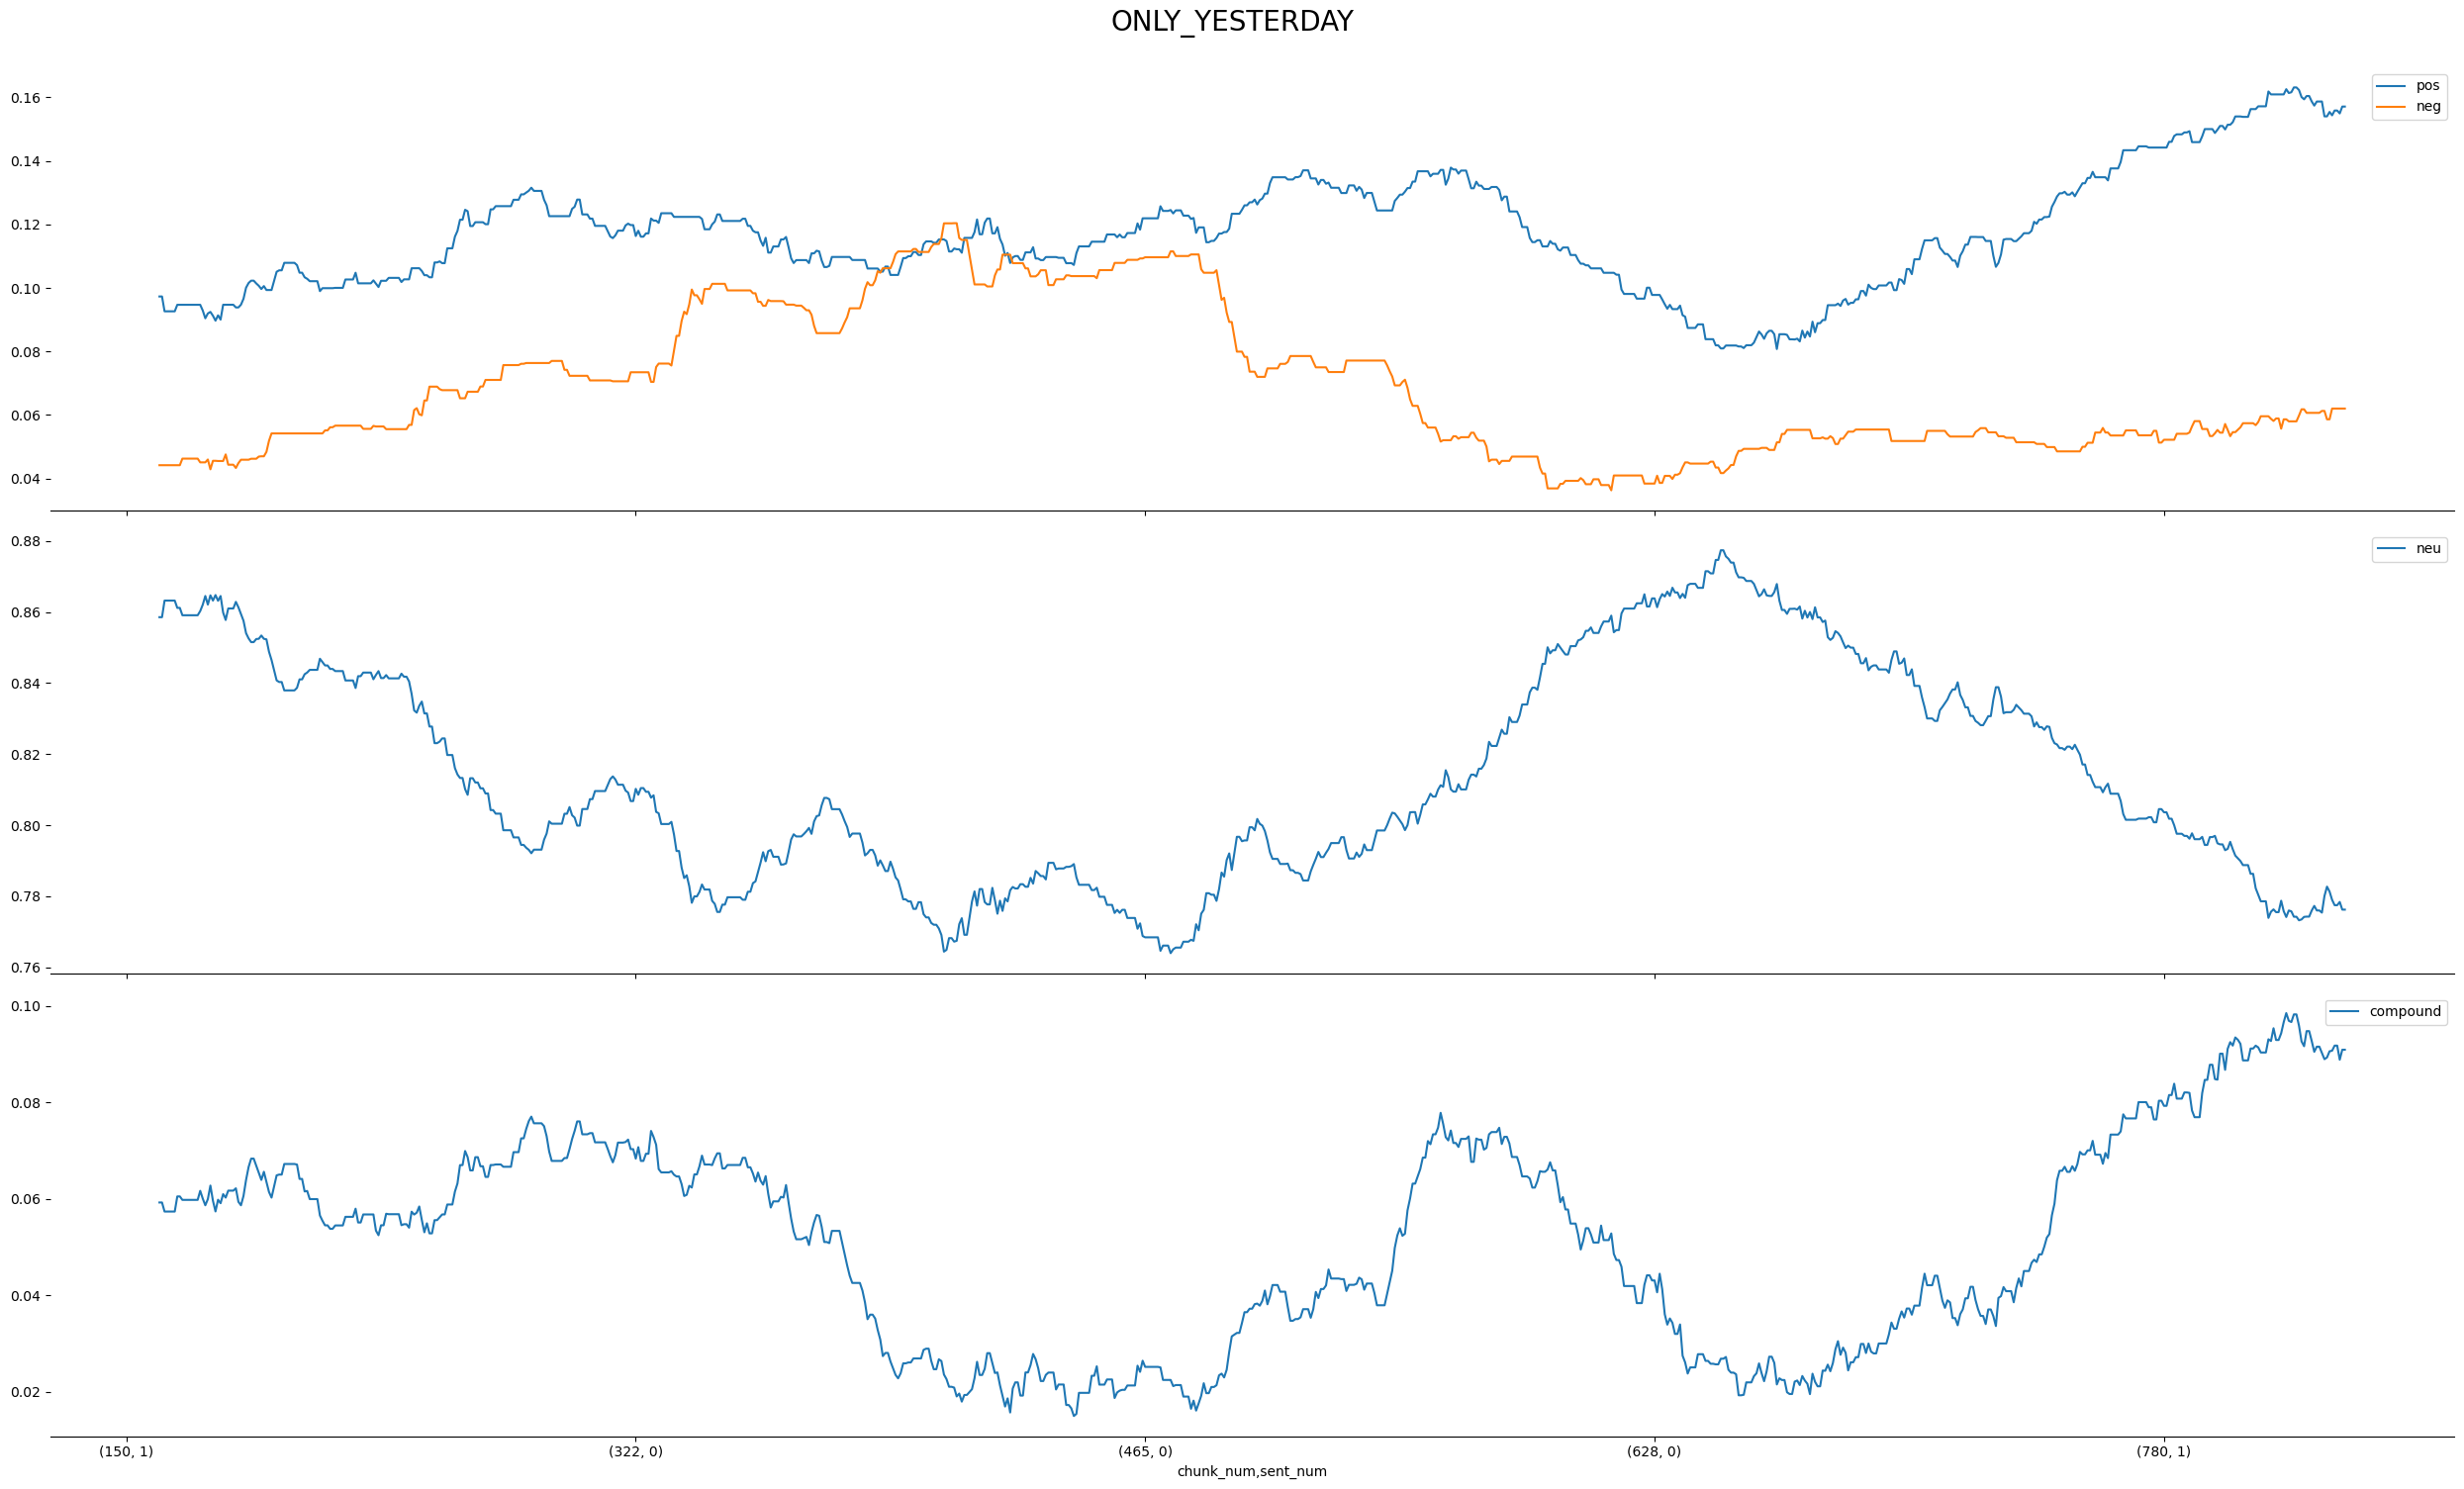

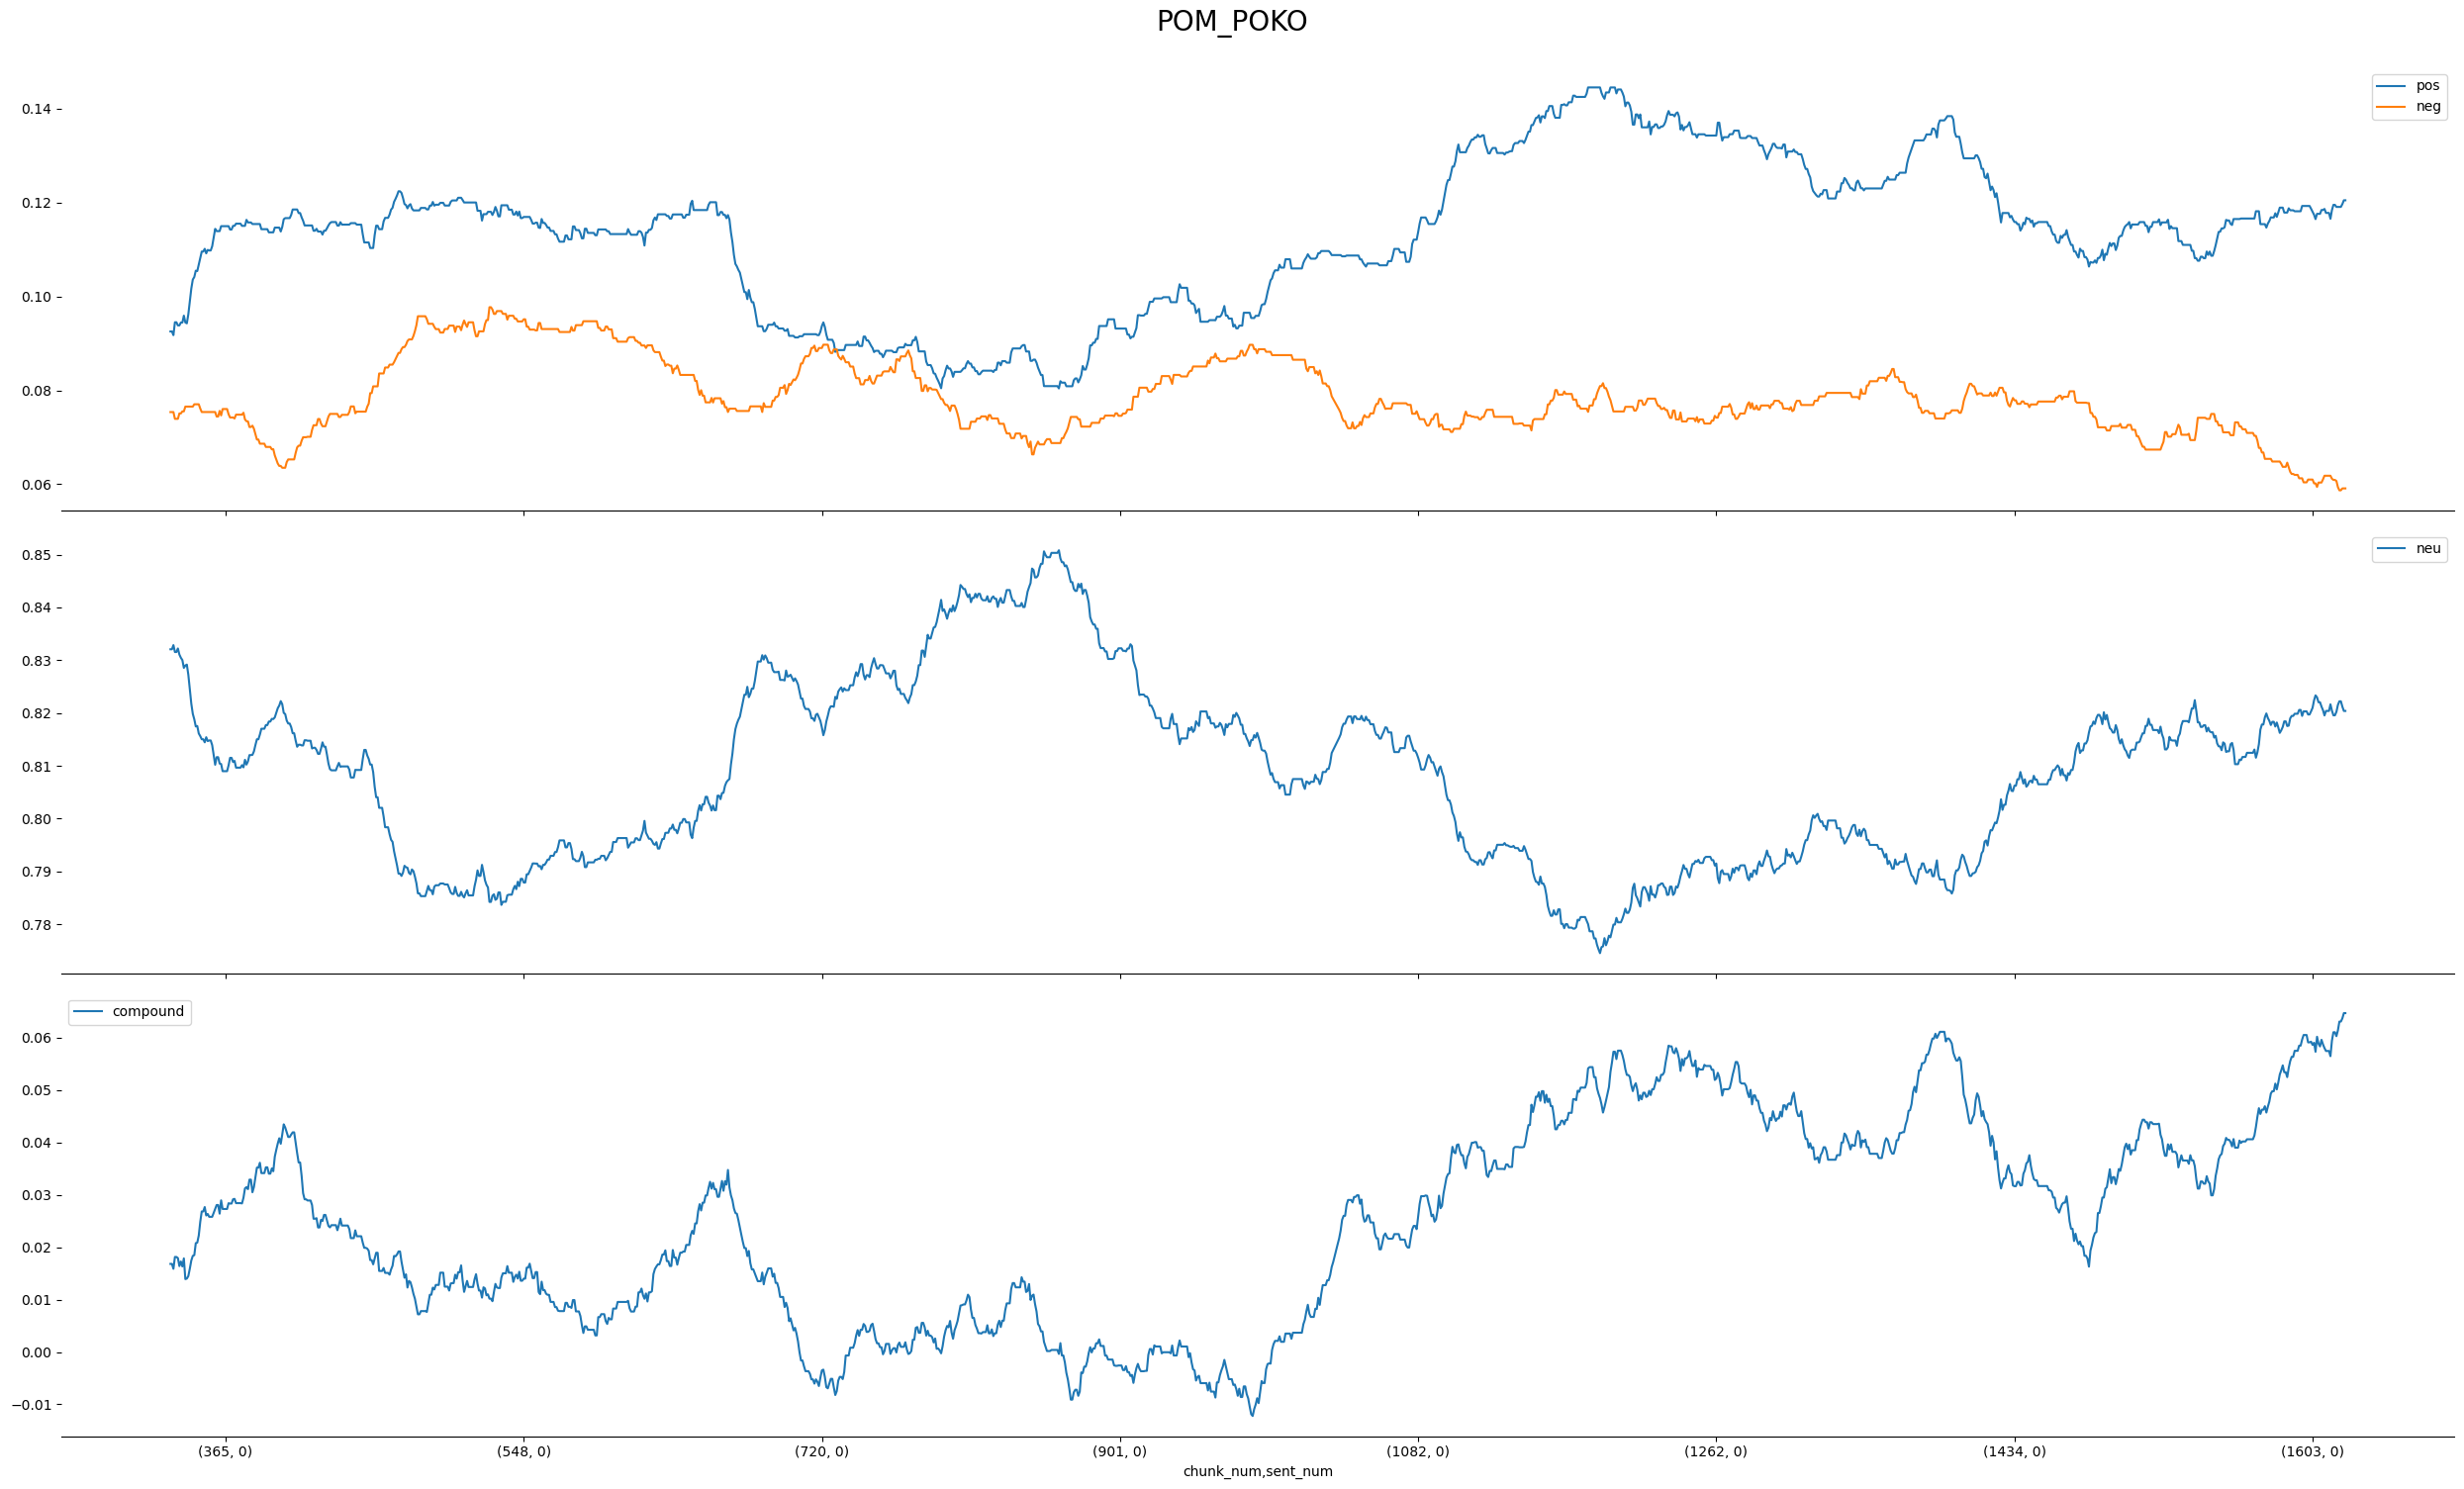

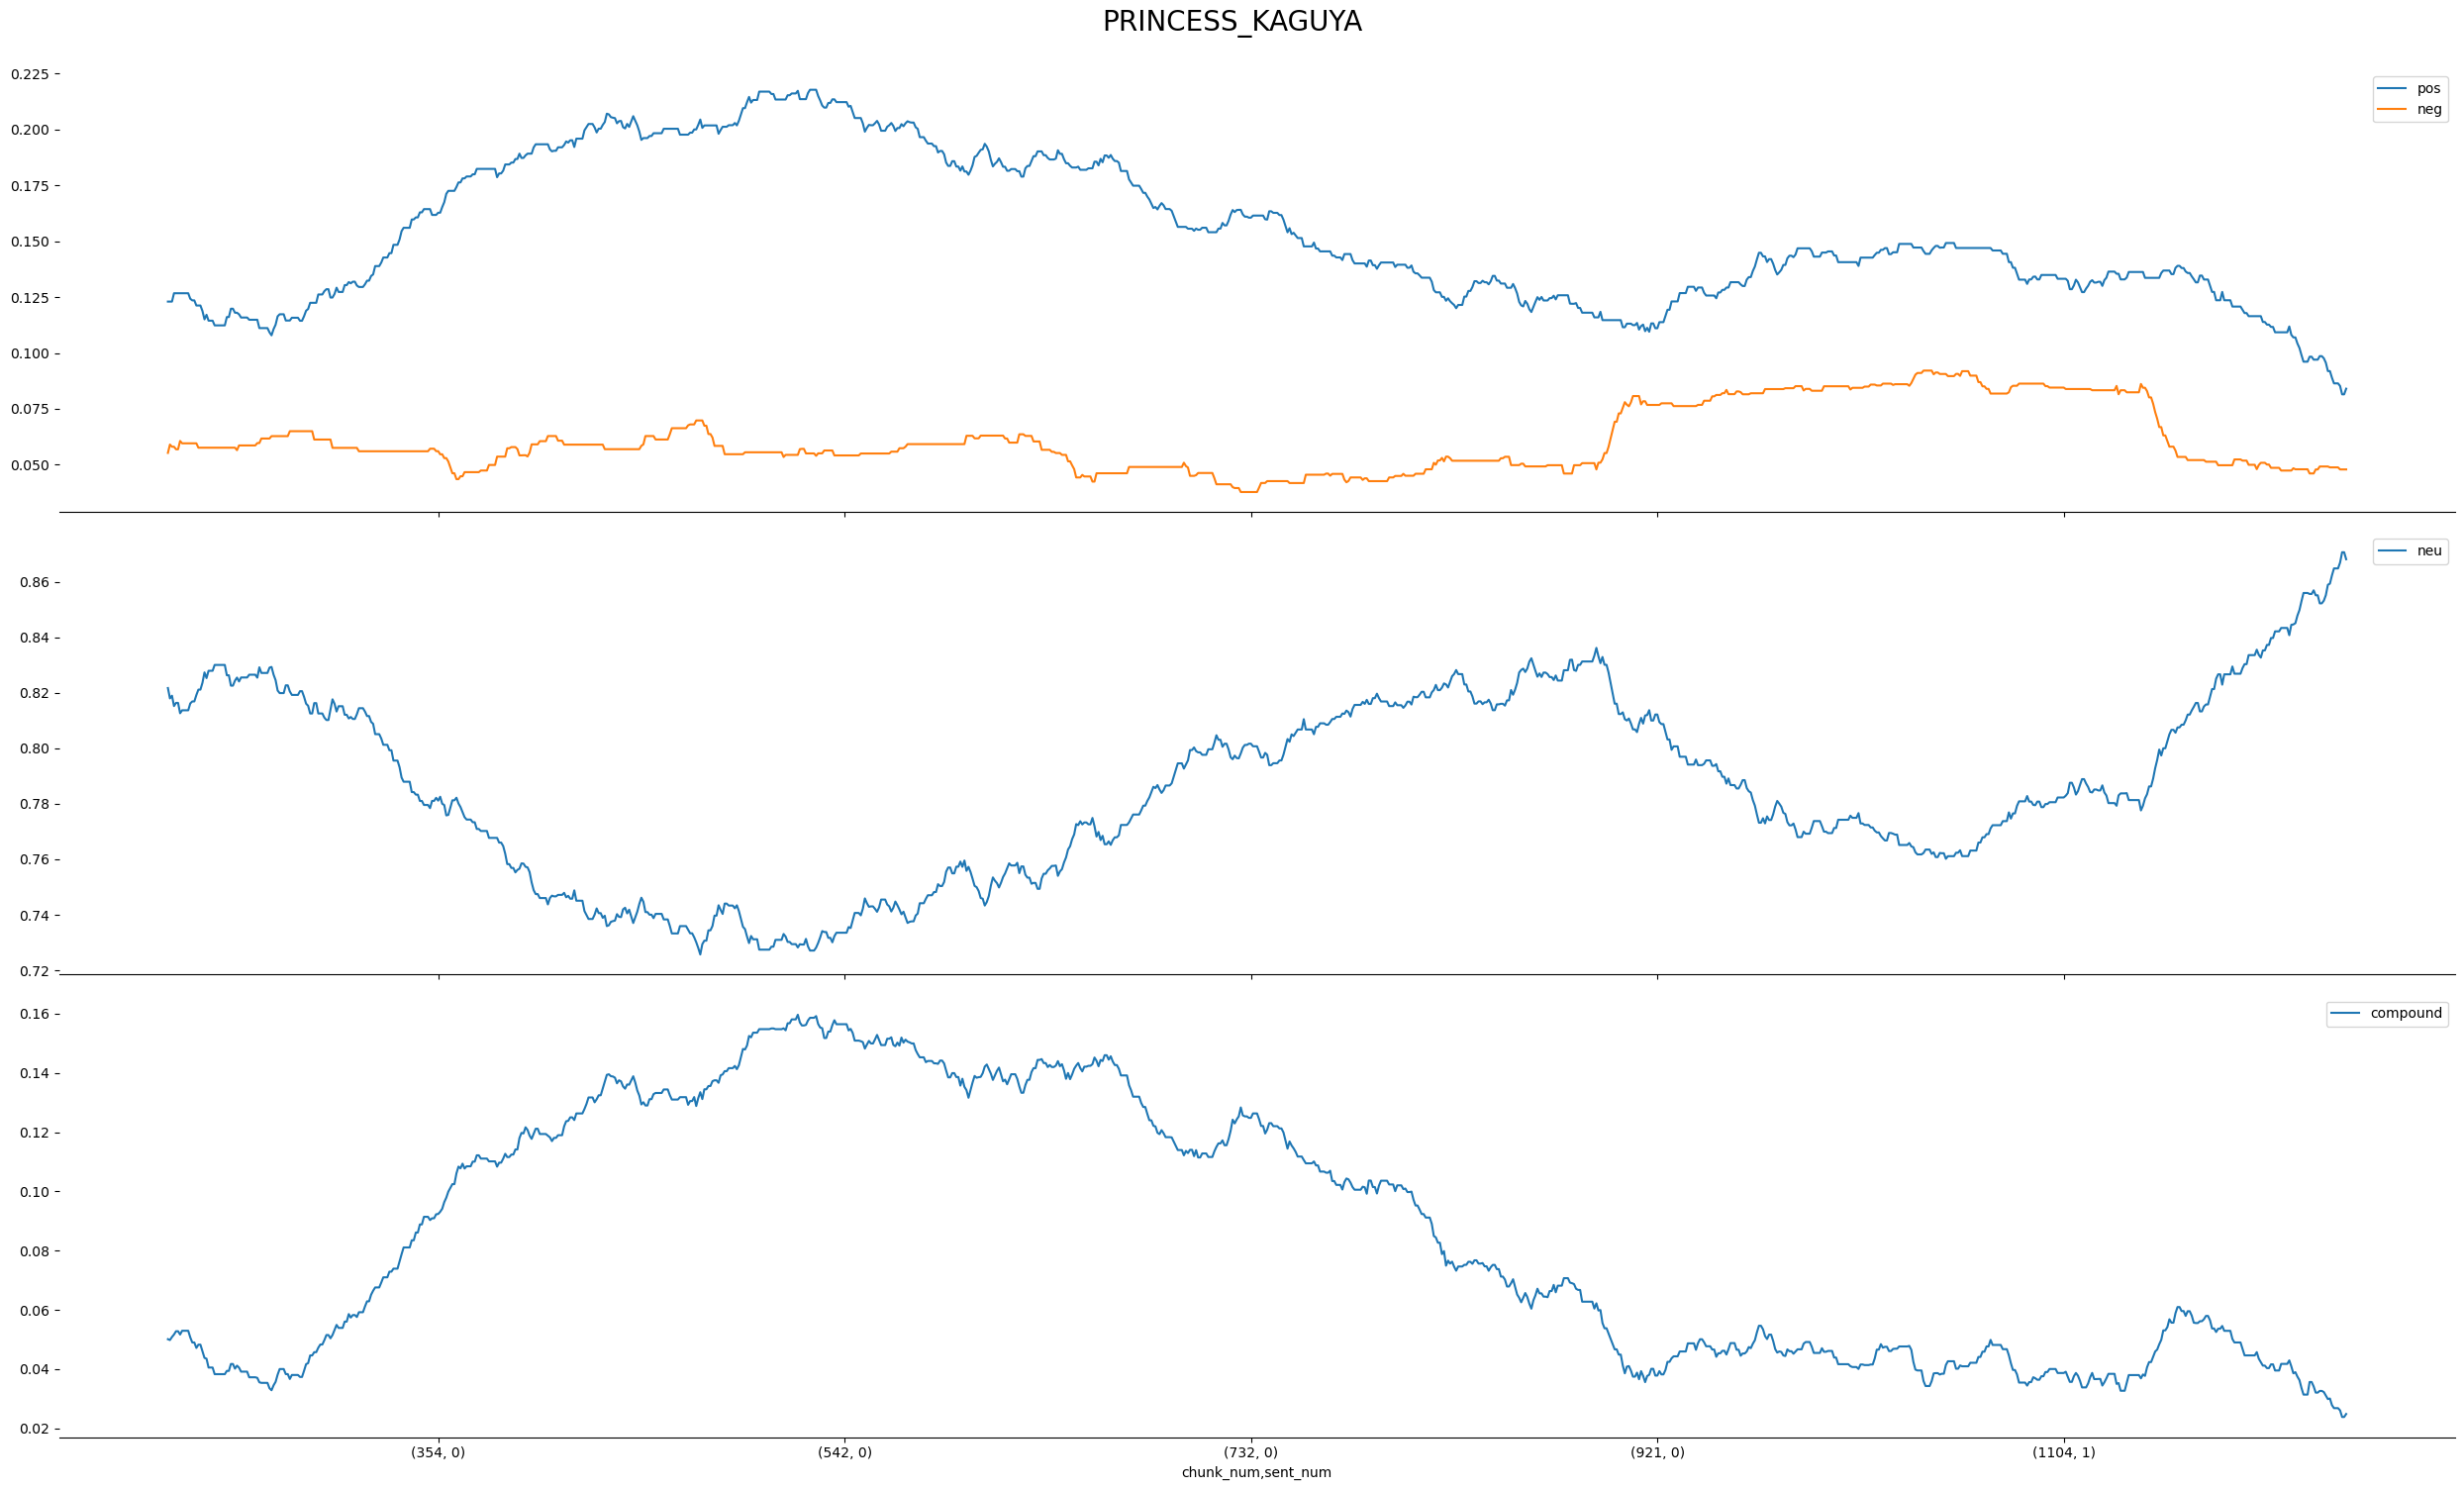

In [93]:
for film in LIB.index:
    plot_film_sa(film)

In [94]:
SPEAKER_SENT

,anger,anticipation,disgust,fear,joy,sadness,surprise,trust,sentiment
speaker,,,,,,,,,
ASHITAKA,0.028037,0.011098,0.017523,0.036215,0.011098,0.036215,0.009346,0.013435,-0.030374
CHIHIRO,0.007744,0.015488,0.011358,0.011358,0.014972,0.020650,0.011358,0.030976,0.007228
Calcifer,0.034906,0.009434,0.037736,0.041509,0.009434,0.044340,0.017925,0.017925,-0.031132
DORA,0.017483,0.020105,0.013112,0.016608,0.016608,0.014860,0.009615,0.016608,-0.008741
Fio,0.013524,0.021480,0.009547,0.019889,0.027844,0.012729,0.007955,0.026253,0.017502
HONJO,0.004981,0.024907,0.007472,0.011208,0.022416,0.012453,0.011208,0.026152,0.017435
Howl,0.007457,0.021626,0.011931,0.018643,0.021626,0.014169,0.012677,0.026846,0.008949
JIRO,0.005663,0.014630,0.002360,0.009910,0.023124,0.011798,0.011326,0.018405,0.014158
KIKI,0.008058,0.020780,0.006785,0.006785,0.025869,0.013995,0.015267,0.019084,0.011026


## Riff 2

<Axes: ylabel='speaker'>

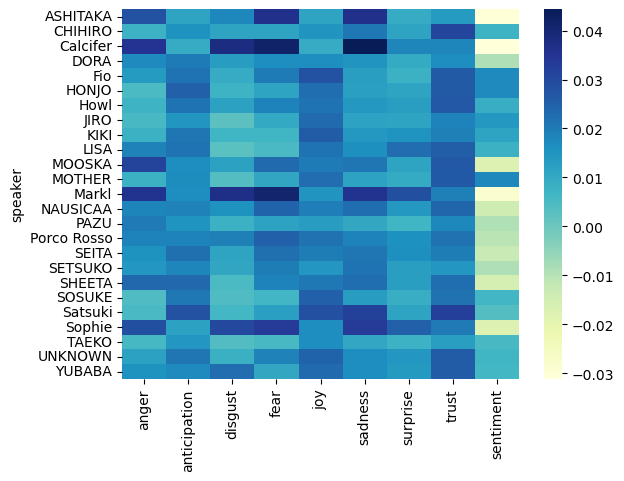

In [95]:
# Filter to top N speakers by line count to avoid noise from minor characters
top_speakers = TOKENS_SA.reset_index()\
    .drop_duplicates(subset=['film_name', 'chunk_num', 'sent_num', 'speaker'])\
    .groupby('speaker').size()\
    .nlargest(25).index

SPEAKER_SENT = TOKENS_SA[TOKENS_SA.speaker.isin(top_speakers)].groupby('speaker')[emo_cols].mean()

sns.heatmap(SPEAKER_SENT, cmap='YlGnBu')

## Save Tables

In [96]:
VOCAB_SENT.to_csv(f'{OUTPUT_DIR}/VOCAB_SENT.csv')
BOW_SENT.to_csv(f'{OUTPUT_DIR}/BOW_SENT.csv')
DOC_SENT.to_csv(f'{OUTPUT_DIR}/DOC_SENT.csv')